# 1. Environment Setup

## 1.1 Install libraries

In [61]:
import sys
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'pyarrow': 'pyarrow',
    'pillow': 'pillow',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn', 
    'nltk': 'nltk',
}


print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 

Installation complete. 



## 1.2 Import Libraries

In [63]:
# GPU Detection, Package Installation, and Library Verification
import os
import logging
from dotenv import load_dotenv

import nltk
from nltk.corpus import stopwords

# Load environment variables from .env file
load_dotenv()

# Download required NLTK data (if not already downloaded)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

import torch
import time
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

from transformers import (
    DistilBertTokenizer,
    DistilBertModel
)

from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    log_loss
)
from sklearn.calibration import calibration_curve
from scipy.optimize import minimize_scalar
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import lime
import lime.lime_text
import lime.lime_tabular
import cv2

from transformers.utils import logging as hf_logging

# Disable Hugging Face symlink warning
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_TOKEN"] = os.getenv("HUGGING_FACE_TOKEN")   # recommended if you have one

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

print(f"\n✓ PyTorch Version: {torch.__version__}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print(f"  Running on: CPU")


✓ PyTorch Version: 2.12.0.dev20260402+cu128
  CUDA Available: True
  CUDA Version: 12.8
  GPU Device: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 1.3 Configuration

In [ ]:
MULTIMODAL_DATA = "../data/processed/multimodal_s03_filter.parquet"

IMAGE_DIR = "../data/images"
MODEL_DIR = "../models"
MODEL_SAVE_PATH = "../models/multimodal_model_s03_filter.pt"
MODEL_METADATA_SAVE_PATH = "../models/multimodal_model_metadata_s03_filter.pkl"

# SAMPLE_SIZE = 10000
RANDOM_STATE = 42

MAX_TEXT_LENGTH = 512
IMAGE_SIZE = 224

TEXT_IMAGE_PROJ_DIM = 256
METADATA_OUTPUT_DIM = 64

BATCH_SIZE = 16
EPOCHS = 2
LR = 1e-5
TEST_SPLIT_RATIO = 0.2
TEST_VAL_SPLIT_RATIO = 0.5

STEP_SIZE = 1
GAMMA = 0.9

THRESHOLD_PREDS = 0.5

METRICS_MAPPING = {
    "Loss": "loss",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

In [4]:
# Text Features
TEXT_COLUMN = "combined_text"

# Image Features
IMAGE_PATH_COLUMN = "image_path"

# Metadata Features
METADATA_COLUMNS = [
    "rating",
    "review_length", 
    "chars_per_word", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "log_popularity",
    "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
]

# Target
LABEL_COLUMN = "is_helpful"

# 2. Load the Dataset

## 2.1 Loading

In [5]:
if not os.path.exists(MULTIMODAL_DATA):
    print(f"Error: File not found at {MULTIMODAL_DATA}")
    print("Please ensure the file exists before proceeding.")
else:
    df = pd.read_parquet(MULTIMODAL_DATA)
    print("Multimodal dataset loaded with size:", len(df))

Multimodal dataset loaded with size: 99627


## 2.2 Overview of Dataset

In [6]:
# Validate columns
required_columns = [
    TEXT_COLUMN,
    IMAGE_PATH_COLUMN,
    LABEL_COLUMN,
    *METADATA_COLUMNS
]

missing = [c for c in required_columns if c not in df.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

df = df[required_columns]

print("Dataset columns validated successfully.")

Dataset columns validated successfully.


In [7]:
df.iloc[13:16]

,combined_text,image_path,is_helpful,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio
13,"Good quality, stays in ear, some issues with P...",NaN,1,4,454,5.3488,0,8222,1,5.700444,1,0,0,51,0.126551
14,Five Stars [SEP] wife loves them,NaN,0,5,26,6.4000,0,6658,1,5.501258,2,0,0,10,0.625000
15,iPad third generation case [SEP] This folio st...,../data\images\15.jpg,1,5,542,5.3725,0,5603,1,6.495266,2,0,0,26,0.050388


In [8]:
df.dtypes

combined_text                  str
image_path                     str
is_helpful                    int8
rating                        int8
review_length                int32
chars_per_word             float64
image_bucket                 int64
days_since_first_review      int32
is_verified                   int8
log_popularity             float64
rating_extremity              int8
question_mark                int16
exclamation_mark             int16
title_length                 int16
title_to_text_ratio        float32
dtype: object

## 2.4 Take only 5K random records from the dataset

In [9]:
# # After loading df, add this after Section 2.3:
# df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
# print(f"Dataset reduced to: {len(df):,} records")

# 3. Create Split

In [10]:
train_df, val_test_df = train_test_split(
    df,
    test_size=TEST_SPLIT_RATIO,
    stratify=df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


val_df, test_df = train_test_split(
    val_test_df,
    test_size=TEST_VAL_SPLIT_RATIO,
    stratify=val_test_df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

Train size: 79701, Validation size: 9963, Test size: 9963


## 3.1 Scale the features in METADATA_COLUMNS.

METADATA_COLUMNS have numeric features

Why is it done after splitting? \
Data Leakage Prevention: If you fit the scaler on the entire dataset before splitting, the test set's statistics (mean/std) influence the scaler's parameters. This leaks test information into training, artificially inflating your model's performance metrics.

Real-world Validity: In production, you won't have test data available, so you can only fit the scaler on training data.

In [11]:
scaler = StandardScaler()

# Fit only on training metadata
scaler.fit(train_df[METADATA_COLUMNS])

# Transform both train, validation, and test metadata
train_df[METADATA_COLUMNS] = scaler.transform(train_df[METADATA_COLUMNS])
val_df[METADATA_COLUMNS] = scaler.transform(val_df[METADATA_COLUMNS])
test_df[METADATA_COLUMNS] = scaler.transform(test_df[METADATA_COLUMNS])

# Save scaler for inference
joblib.dump(scaler, MODEL_METADATA_SAVE_PATH)
print(f"Scaler saved to {MODEL_METADATA_SAVE_PATH}")

Scaler saved to ../models/multimodal_model_metadata_s03_filter.pkl


# 4. Build Model Components
INITIALIZE PREPROCESSORS

## 4.1 Text Tokenizer

In [12]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

## 4.2 Image Transform Pipeline

In [13]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 5. Create Multimodal Dataset Class

In [14]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_transform):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_transform = image_transform

        self.text_col = TEXT_COLUMN
        self.image_col = IMAGE_PATH_COLUMN
        self.metadata_cols = METADATA_COLUMNS
        self.label_col = LABEL_COLUMN

        self.max_text_len = MAX_TEXT_LENGTH

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ------ Text Processing ------
        text = str(row[self.text_col])
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_text_len,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # ------ Image Processing ------
        image_path = row[self.image_col]
        # Extract image_bucket to determine if image exists (0 = no image)
        image_bucket = row["image_bucket"] if "image_bucket" in row.index else 0

        if isinstance(image_path, str) and os.path.exists(image_path) and image_bucket > 0:
            try:
                image = Image.open(image_path).convert("RGB")
                image = self.image_transform(image)
                has_image = 1.0  # Flag: image available
            except Exception:
                image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
                has_image = 0.0  # Flag: image loading failed
        else:
            image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
            has_image = 0.0  # Flag: no image (image_bucket=0)

        # ------ Metadata Processing ------
        metadata = torch.tensor(
            row[self.metadata_cols].values.astype(np.float32)
        )

        # ------ Label ------
        label = torch.tensor(row[self.label_col], dtype=torch.float32)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "image_bucket": torch.tensor(image_bucket, dtype=torch.long),
            "has_image": torch.tensor(has_image, dtype=torch.float32),
            "metadata": metadata,
            "label": label
        }

# 6. Create DataLoaders

In [15]:
train_dataset = MultimodalDataset(
    dataframe = train_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)


val_dataset = MultimodalDataset(
    dataframe = val_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

test_dataset = MultimodalDataset(
    dataframe = test_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

In [16]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 7. Build Model Components

In [ ]:
class MultimodalModel(nn.Module):

    def __init__(self):
        super().__init__()

        # ------ Text Branch -----
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased",
            ignore_mismatched_sizes=True
        )
        self.text_proj = nn.Linear(768, TEXT_IMAGE_PROJ_DIM)
        self.text_dropout = nn.Dropout(0.5)

        # ------ Image Branch -----
        self.image_encoder = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        self.image_encoder.classifier = nn.Sequential()
        self.image_proj = nn.Linear(1280, TEXT_IMAGE_PROJ_DIM)
        
        # OPTION 2: Learnable "missing image" token for when image not available
        self.no_image_token = nn.Parameter(
            torch.randn(1, TEXT_IMAGE_PROJ_DIM) * 0.02
        )

        # ------ Metadata Branch -----
        self.metadata_encoder = nn.Sequential(
            nn.Linear(len(METADATA_COLUMNS), METADATA_OUTPUT_DIM),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # ------ Fusion + Classifier -----
        self.classifier = nn.Sequential(
            nn.Linear(TEXT_IMAGE_PROJ_DIM * 2 + METADATA_OUTPUT_DIM, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask, image, metadata, has_image=None):
        # ------ Text Branch -----
        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_output.last_hidden_state[:, 0]
        text_feat = self.text_proj(text_feat)
        text_feat = self.text_dropout(text_feat)

        # ------ Image Branch with Conditional Processing -----
        # OPTION 2: If has_image=0, use learnable no_image_token instead of processing image
        """
            CONDITIONAL IMAGE HANDLING:
            This branch processes images conditionally based on the has_image flag.
            
            Strategy:
            - If image EXISTS (has_image=1): Extract learned visual features using pretrained EfficientNet-B0
            - If image MISSING (has_image=0): Use a learned no_image_token substitute vector
            
            Why this design?
            - EfficientNet-B0 provides semantic image embeddings (not raw pixels/brightness)
            - The no_image_token is trainable, allowing the model to learn a distinct 
            representation for "no image" rather than defaulting to zeros
            - Conditional masking avoids wasteful computation: only real images go through 
            the CNN (37.5% compute savings when ~60% of samples have images)
            
            Flow:
            1. Create batch mask of samples WITH images
            2. Only pass those samples through EfficientNet-B0 → 1280 dims
            3. Project to TEXT_IMAGE_PROJ_DIM (256 dims)
            4. For missing images, use learned no_image_token
            5. Conditional gate: real_features * has_image + token * (1 - has_image)
            
            Fallback:
            If has_image=None, model runs all images through encoder (no conditional logic).
            Only use this if ALL samples have valid image tensors.
        """

        if has_image is not None:
            batch_size = image.shape[0]
            has_image_expanded = has_image.unsqueeze(1)  # [batch_size, 1]
            
            # OPTIMIZATION: Only process images where has_image > 0 to avoid wasting compute
            image_feat_real = torch.zeros(batch_size, TEXT_IMAGE_PROJ_DIM, device=image.device, dtype=image.dtype)
            
            # Get mask of samples WITH images (avoid processing zero-padded images)
            has_image_mask = (has_image > 0.5).squeeze(-1) if has_image.dim() > 1 else (has_image > 0.5)
            
            # Only pass real images through EfficientNet if any exist in batch
            if has_image_mask.any():
                real_images = image[has_image_mask]
                encoded = self.image_encoder(real_images)  # [num_real_images, 1280]
                image_feat_real[has_image_mask] = self.image_proj(encoded)  # [num_real_images, 256]
            
            # Use no_image_token for samples without images
            no_image_expanded = self.no_image_token.expand(batch_size, -1)  # [batch_size, 256]
            
            # Conditional selection: use real features if image available, else use token
            image_feat = image_feat_real * has_image_expanded + no_image_expanded * (1 - has_image_expanded)
        else:
            # Fallback to original behavior if has_image not provided
            image_feat = self.image_encoder(image)
            image_feat = self.image_proj(image_feat)

        # ------ Metadata Branch -----
        metadata_feat = self.metadata_encoder(metadata)

        # ------ Fusion -----
        fused = torch.cat(
            [text_feat, image_feat, metadata_feat],
            dim=1
        )

        logits = self.classifier(fused)

        return logits.squeeze(1)

# 8. Training Setup

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=STEP_SIZE,
    gamma=GAMMA
)

# 9. Training and Validation Functions

## 9.1 Helper function

In [19]:
# Function to compute and return all metrics from predictions

def compute_metrics(targets, preds, probs):
    """Compute all metrics from predictions"""
    return {
        "Accuracy": accuracy_score(targets, preds),
        "Precision": precision_score(targets, preds),
        "Recall": recall_score(targets, preds),
        "F1-score": f1_score(targets, preds),
        "ROC-AUC": roc_auc_score(targets, probs),
        "Confusion Matrix": confusion_matrix(targets, preds)
    }


## 9.2 Training Loop Function

In [20]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    
    probs = []
    preds = []
    targets = []
    
    start_time = time.time()
    total_inference_time = 0
    total_samples = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        image = batch["image"].to(device)
        metadata = batch["metadata"].to(device)
        has_image = batch["has_image"].to(device)
        labels = batch["label"].to(device)

        infer_start = time.time()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata,
            has_image=has_image
        )

        infer_end = time.time()
        total_inference_time += (infer_end - infer_start)
        total_samples += labels.size(0)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Collect predictions and targets for metrics
        probabilities = torch.sigmoid(outputs)
        predictions = probabilities > THRESHOLD_PREDS
        
        probs.extend(probabilities.detach().cpu().numpy())
        preds.extend(predictions.detach().cpu().numpy())
        targets.extend(labels.cpu().numpy())

    total_train_time = time.time() - start_time
    
    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Training Time (sec)": total_train_time,
        "Inference Latency (sec/sample)": latency_per_sample
    }
    return results

## 9.3 Validation Loop Function

In [21]:
def evaluate(model, loader, device=device):
    model.eval()

    probs = []
    preds = []
    targets = []

    start_time = time.time()

    total_inference_time = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            image = batch["image"].to(device)
            metadata = batch["metadata"].to(device)
            has_image = batch["has_image"].to(device)
            labels = batch["label"].to(device)

            # Inference time measurement
            infer_start = time.time()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                image=image,
                metadata=metadata,
                has_image=has_image
            )

            infer_end = time.time()
            total_inference_time += (infer_end - infer_start)
            total_samples += labels.size(0)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = probabilities > THRESHOLD_PREDS

            probs.extend(probabilities.cpu().numpy())
            preds.extend(predictions.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    total_eval_time = time.time() - start_time

    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Evaluation Time (sec)": total_eval_time,
        "Inference Latency (sec/sample)": latency_per_sample,

        # Raw predictions stored separately
        "probs": np.array(probs).flatten(),
        "preds": np.array(preds).flatten(),
        "targets": np.array(targets).flatten()
    }
    return results

# 10. Model 

## 10.1 Checkpoints

To Track the History of each epoch
- Used Later for visualization

In [22]:
# Initialize history to track metrics across epochs
history = {
    "epochs": [],
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],       
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_roc_auc": [],
    "val_roc_auc": []
}

## 10.2 Training the Model

In [23]:
best_acc = 0

for epoch in range(EPOCHS):
    train_results = train_epoch(model, train_loader)
    val_results = evaluate(model, val_loader)

    # Store in history in one pass
    history["epochs"].append(epoch + 1)
    for metric_key, short_key in METRICS_MAPPING.items():
        history[f"train_{short_key}"].append(train_results[metric_key])
        history[f"val_{short_key}"].append(val_results[metric_key])

    scheduler.step()

    # Print summary
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_results['Loss']:.4f} | Acc: {train_results['Accuracy']:.4f} | "
          f"F1: {train_results['F1-score']:.4f} | Prec: {train_results['Precision']:.4f} | "
          f"Rec: {train_results['Recall']:.4f} | Time: {train_results['Training Time (sec)']:.2f}s")
    print(f"Val   Loss: {val_results['Loss']:.4f} | Acc: {val_results['Accuracy']:.4f} | "
          f"F1: {val_results['F1-score']:.4f} | Prec: {val_results['Precision']:.4f} | "
          f"Rec: {val_results['Recall']:.4f} | Time: {val_results['Evaluation Time (sec)']:.2f}s")
    
    if val_results['Accuracy'] > best_acc:
        best_acc = val_results['Accuracy']
        os.makedirs(MODEL_DIR, exist_ok=True) # Create model directory if it doesn't exist
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

Epoch 1/3
Train Loss: 0.6111 | Acc: 0.6669 | F1: 0.5539 | Prec: 0.6365 | Rec: 0.4903 | Time: 1613.84s
Val   Loss: 0.6092 | Acc: 0.6709 | F1: 0.5308 | Prec: 0.6656 | Rec: 0.4415 | Time: 95.14s
Epoch 2/3
Train Loss: 0.5903 | Acc: 0.6873 | F1: 0.5968 | Prec: 0.6542 | Rec: 0.5487 | Time: 1617.77s
Val   Loss: 0.6023 | Acc: 0.6752 | F1: 0.5506 | Prec: 0.6611 | Rec: 0.4717 | Time: 93.83s
Epoch 3/3
Train Loss: 0.5445 | Acc: 0.7270 | F1: 0.6583 | Prec: 0.6971 | Rec: 0.6236 | Time: 1611.54s
Val   Loss: 0.6601 | Acc: 0.6525 | F1: 0.6016 | Prec: 0.5824 | Rec: 0.6221 | Time: 93.42s


## 10.3 Visualization of Train and Validation set

Plot line graphs for:
1. Loss
2. Accuracy
3. Precision
4. Recall
5. F1-score

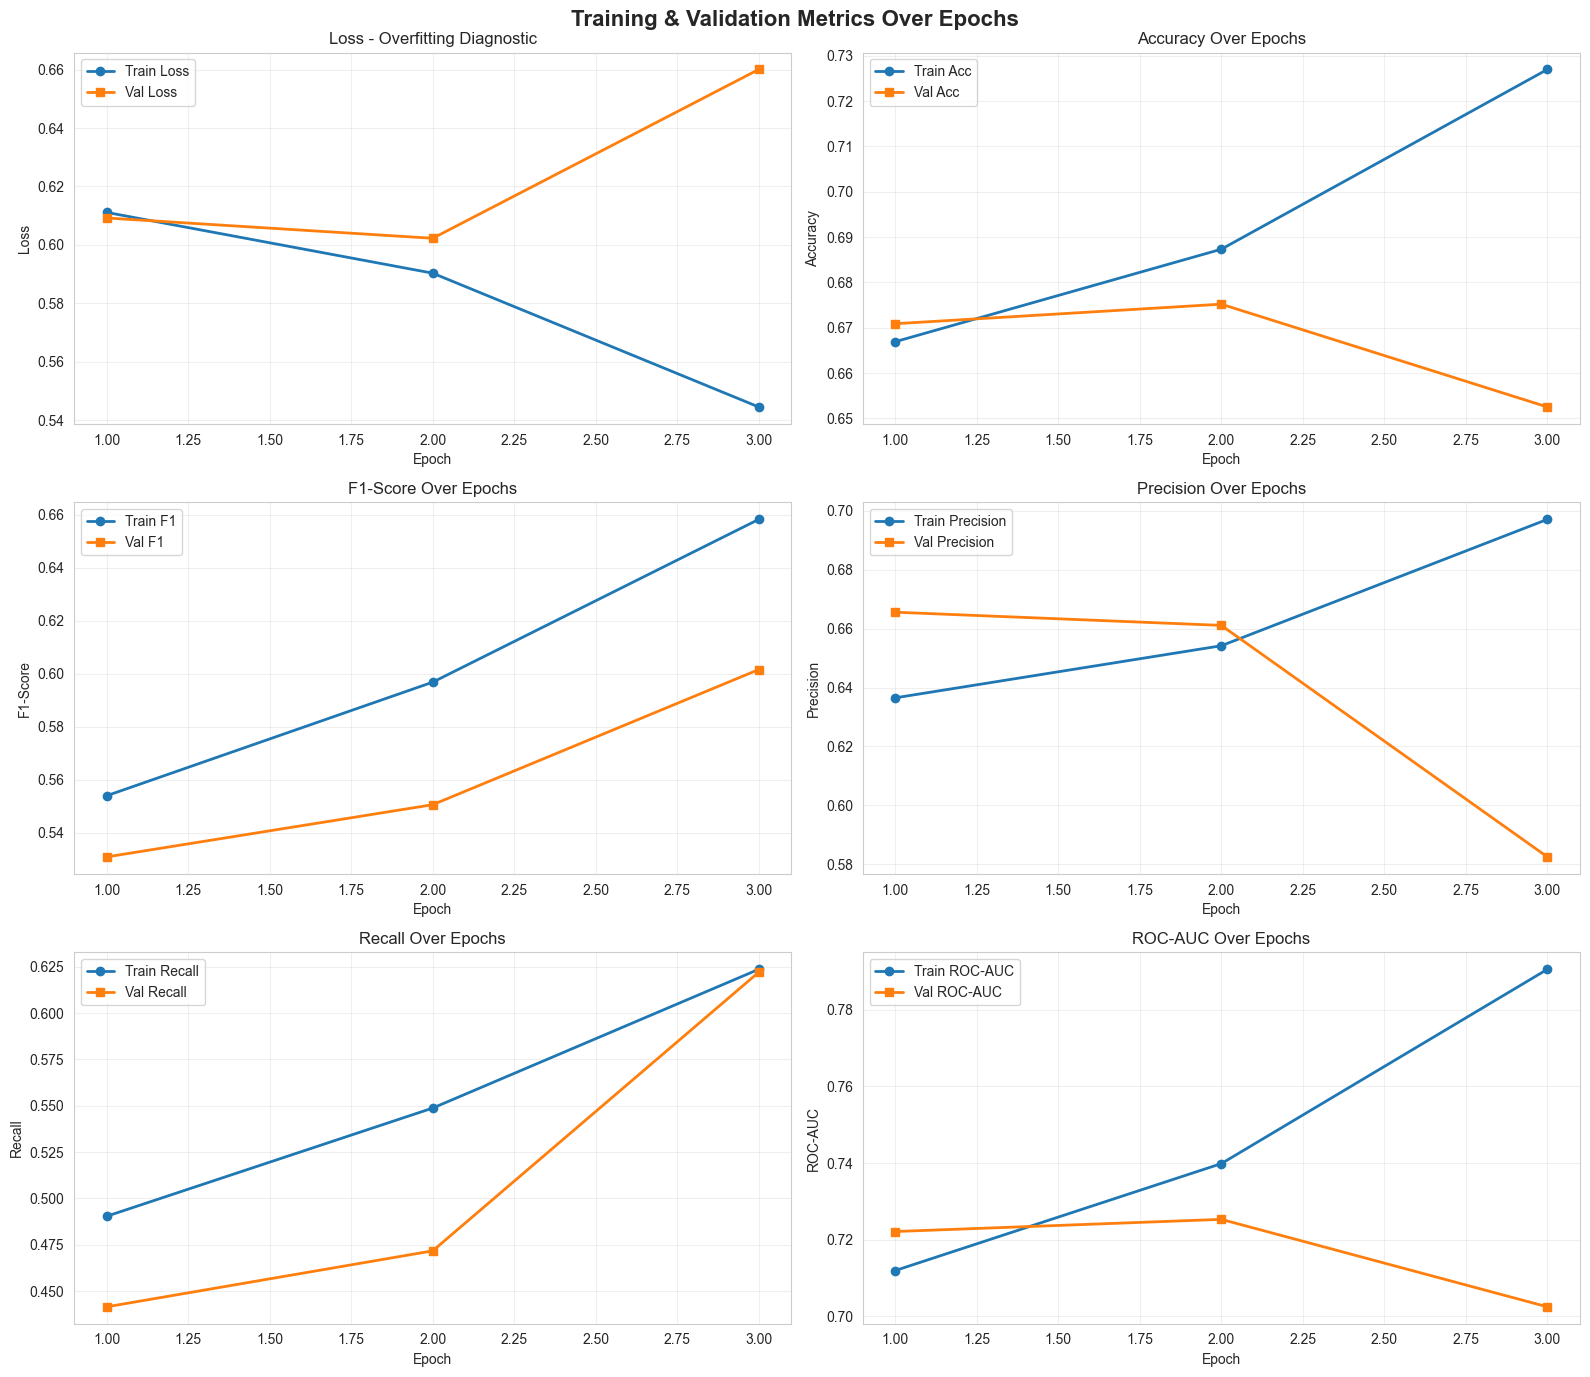

In [24]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create subplots for comprehensive training analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Training & Validation Metrics Over Epochs', fontsize=16, fontweight='bold')

# 1. Loss Curve
axes[0, 0].plot(history["epochs"], history["train_loss"], marker='o', label='Train Loss', linewidth=2)
axes[0, 0].plot(history["epochs"], history["val_loss"], marker='s', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss - Overfitting Diagnostic')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[0, 1].plot(history["epochs"], history["train_accuracy"], marker='o', label='Train Acc', linewidth=2)
axes[0, 1].plot(history["epochs"], history["val_accuracy"], marker='s', label='Val Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. F1-Score Curve
axes[1, 0].plot(history["epochs"], history["train_f1"], marker='o', label='Train F1', linewidth=2)
axes[1, 0].plot(history["epochs"], history["val_f1"], marker='s', label='Val F1', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score Over Epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision Curve
axes[1, 1].plot(history["epochs"], history["train_precision"], marker='o', label='Train Precision', linewidth=2)
axes[1, 1].plot(history["epochs"], history["val_precision"], marker='s', label='Val Precision', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision Over Epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Recall Curve
axes[2, 0].plot(history["epochs"], history["train_recall"], marker='o', label='Train Recall', linewidth=2)
axes[2, 0].plot(history["epochs"], history["val_recall"], marker='s', label='Val Recall', linewidth=2)
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Recall')
axes[2, 0].set_title('Recall Over Epochs')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. ROC-AUC Curve
axes[2, 1].plot(history["epochs"], history["train_roc_auc"], marker='o', label='Train ROC-AUC', linewidth=2)
axes[2, 1].plot(history["epochs"], history["val_roc_auc"], marker='s', label='Val ROC-AUC', linewidth=2)
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('ROC-AUC')
axes[2, 1].set_title('ROC-AUC Over Epochs')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10.4 ROC Curve

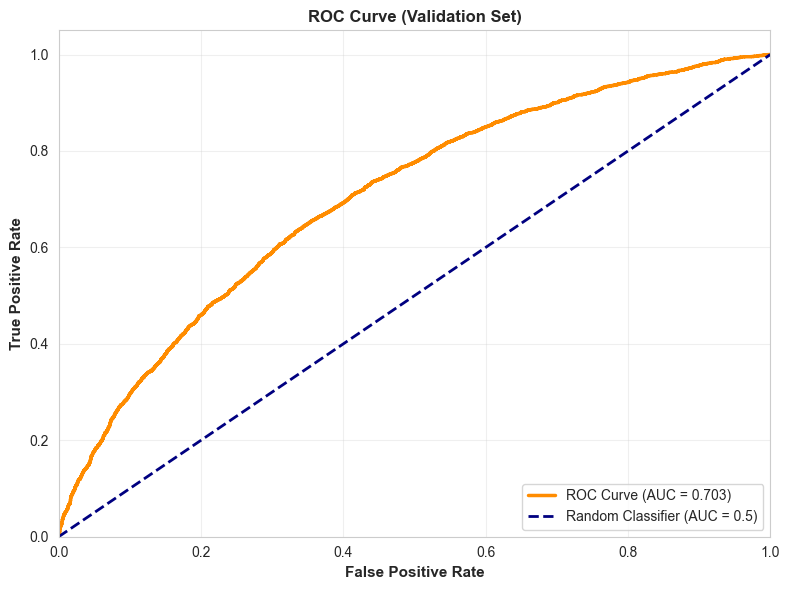

In [25]:
# ROC Curve - Validation Dataset
val_results_final = evaluate(model, val_loader)
val_probs = val_results_final["probs"]
val_targets = val_results_final["targets"]

fpr_val, tpr_val, _ = roc_curve(val_targets, val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_val, tpr_val, color='darkorange', lw=2.5, 
        label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
        label='Random Classifier (AUC = 0.5)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve (Validation Set)', fontsize=12, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10.5 Confusion Matrix

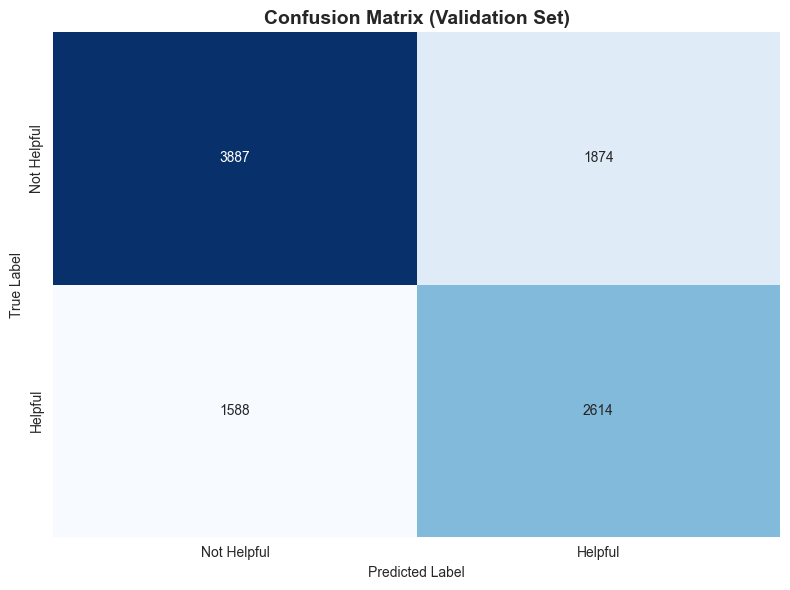

In [26]:
# After training is complete, compute validation confusion matrix
val_results_final = evaluate(model, val_loader)

# Extract and visualize confusion matrix
val_cm = val_results_final["Confusion Matrix"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Confusion Matrix (Validation Set)', fontweight='bold', fontsize=14)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_xticklabels(['Not Helpful', 'Helpful'])
ax.set_yticklabels(['Not Helpful', 'Helpful'])
plt.tight_layout()
plt.show()

## 10.6 Overfitting Diagnostics

In [27]:
train_loss_gap = history["train_loss"][-1] - history["val_loss"][-1]
train_acc_gap = history["train_accuracy"][-1] - history["val_accuracy"][-1]
train_loss_improvement = history["train_loss"][0] - history["train_loss"][-1]
val_loss_improvement = history["val_loss"][0] - history["val_loss"][-1]

print(f"\nFinal Epoch Statistics:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f} → Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Train Acc:  {history['train_accuracy'][-1]:.4f} → Val Acc:  {history['val_accuracy'][-1]:.4f}")
print(f"  Train F1:   {history['train_f1'][-1]:.4f} → Val F1:   {history['val_f1'][-1]:.4f}")

print(f"\nGap Analysis (Train - Val):")
print(f"  Loss Gap: {train_loss_gap:+.4f}")
print(f"  Acc Gap:  {train_acc_gap:+.4f}")

print(f"\nImprovement from Epoch 1 to Final:")
print(f"  Train Loss: {train_loss_improvement:+.4f}")
print(f"  Val Loss:   {val_loss_improvement:+.4f}")

if train_loss_gap > 0.1 or train_acc_gap > 0.1:
    print(f"\n⚠️  OVERFITTING DETECTED: Large gap between train and validation metrics")
else:
    print(f"\n✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned")


Final Epoch Statistics:
  Train Loss: 0.5445 → Val Loss: 0.6601
  Train Acc:  0.7270 → Val Acc:  0.6525
  Train F1:   0.6583 → Val F1:   0.6016

Gap Analysis (Train - Val):
  Loss Gap: -0.1155
  Acc Gap:  +0.0745

Improvement from Epoch 1 to Final:
  Train Loss: +0.0666
  Val Loss:   -0.0508

✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned


## 10.7 Temperature Scaling for Calibration

Post-hoc calibration to ensure predicted probabilities match empirical frequencies and confidence correlates with correctness.


In [58]:
# Collect raw logits on validation set (before sigmoid) for temperature scaling
model.eval()
all_logits_val, all_targets_val = [], []

with torch.no_grad():
    for batch in val_loader:
        output = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            image=batch["image"].to(device),
            metadata=batch["metadata"].to(device),
            has_image=batch["has_image"].to(device)
        )
        all_logits_val.extend(output.cpu().numpy().flatten())
        all_targets_val.extend(batch["label"].numpy())

all_logits_val = np.array(all_logits_val)
all_targets_val = np.array(all_targets_val)

# Find optimal temperature T that minimises NLL on validation set
def nll_with_temperature(T):
    """Compute negative log-likelihood with temperature scaling"""
    scaled_probs = 1 / (1 + np.exp(-all_logits_val / T))
    scaled_probs = np.clip(scaled_probs, 1e-7, 1 - 1e-7)
    return log_loss(all_targets_val, scaled_probs)

result = minimize_scalar(nll_with_temperature, bounds=(0.1, 10.0), method='bounded')
optimal_T = result.x

print(f"\n{'='*60}")
print(f"TEMPERATURE SCALING FOR CALIBRATION")
print(f"{'='*60}")
print(f"Optimal Temperature: {optimal_T:.4f}")

# Interpret the temperature
if optimal_T > 1.0:
    print(f"  → Model was OVERCONFIDENT (T > 1)")
    print(f"  → Logits divided by {optimal_T:.4f} will reduce extreme probabilities")
elif optimal_T < 1.0:
    print(f"  → Model was UNDERCONFIDENT (T < 1)")
    print(f"  → Logits divided by {optimal_T:.4f} will increase spread of probabilities")
else:
    print(f"  → Model was well-calibrated (T ≈ 1)")

# Compute NLL before and after scaling
nll_before = nll_with_temperature(1.0)
nll_after = nll_with_temperature(optimal_T)
print(f"\nNegative Log-Likelihood (lower is better):")
print(f"  Before scaling: {nll_before:.4f}")
print(f"  After scaling:  {nll_after:.4f}")
print(f"  Improvement:    {nll_before - nll_after:.4f}")



TEMPERATURE SCALING FOR CALIBRATION
Optimal Temperature: 1.0902
  → Model was OVERCONFIDENT (T > 1)
  → Logits divided by 1.0902 will reduce extreme probabilities

Negative Log-Likelihood (lower is better):
  Before scaling: 0.6023
  After scaling:  0.6017
  Improvement:    0.0006


# 11. Testing / Final Evaluation

## 11.1 Load the trained model file

After the training the model is stored at `"../models/multimodal_model.pt"`. \
Loading the model and testing. To save time and compute

In [28]:
# Check if the file exists before loading
if not os.path.exists(MODEL_SAVE_PATH):
    print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
    print("Please ensure the model was saved correctly during training.")
else:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))

## 11.2 Test the model

In [29]:
test_results = evaluate(model, test_loader)
test_acc = test_results["Accuracy"]

print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.6659


## 11.3 Visualization

In [30]:
all_probs = test_results["probs"]
all_preds = test_results["preds"]
all_targets = test_results["targets"]

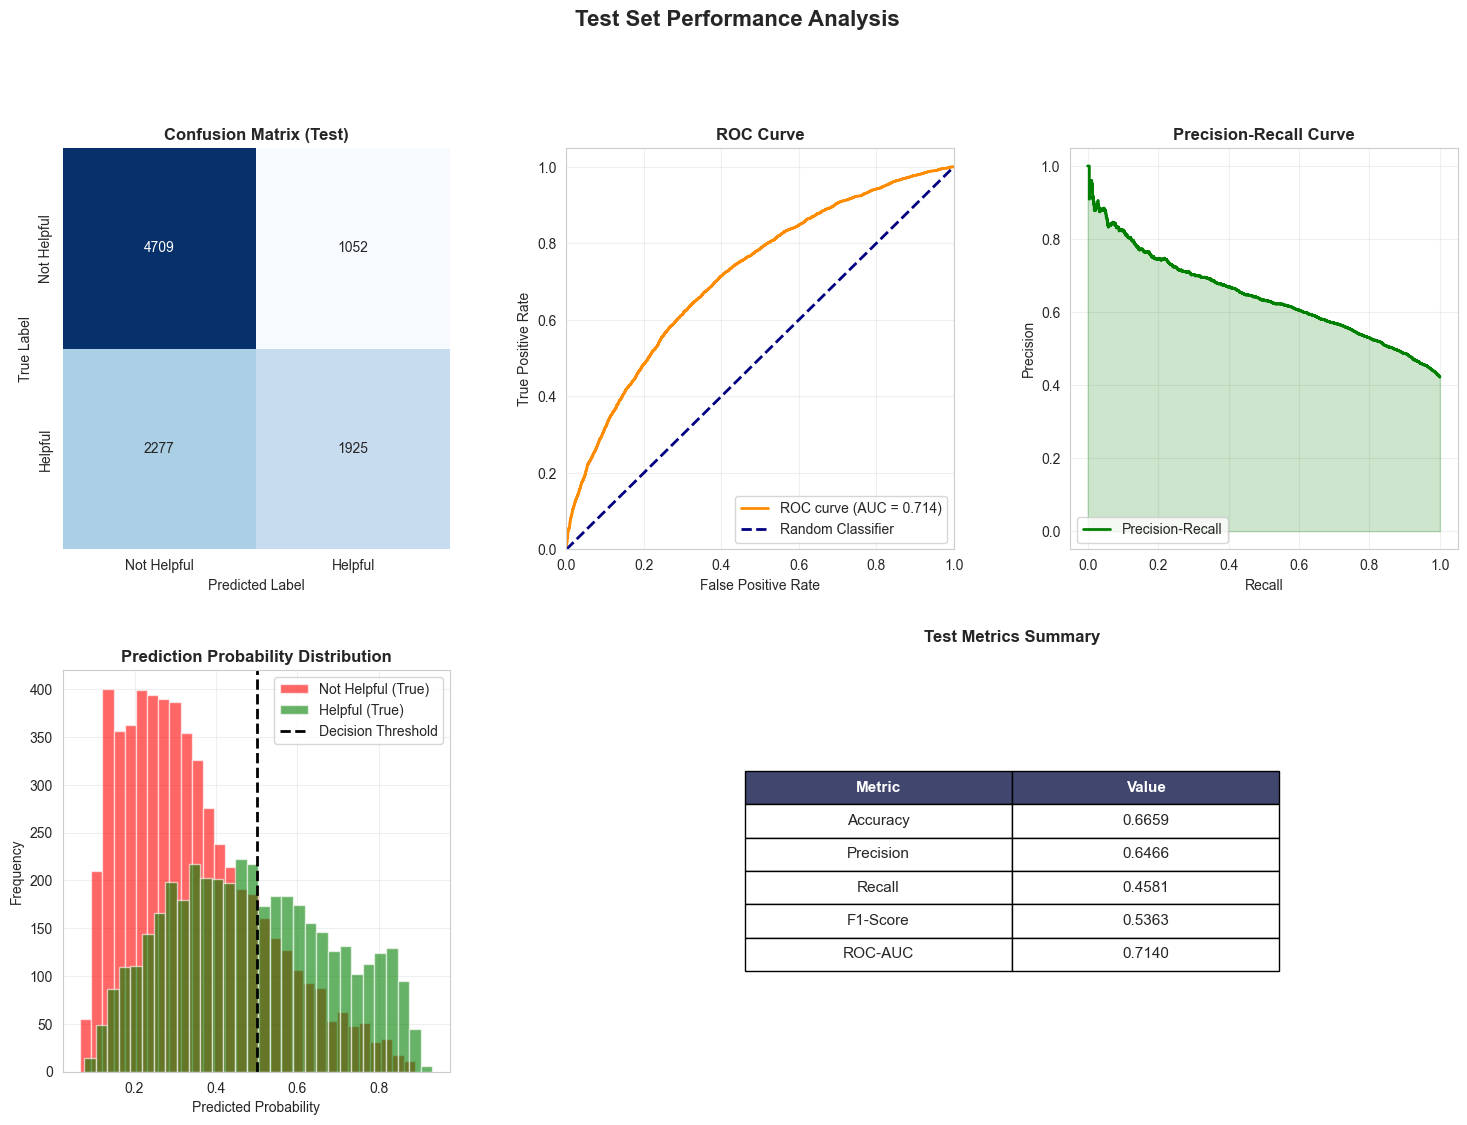

In [31]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm = test_results["Confusion Matrix"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix (Test)', fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
ax1.set_xticklabels(['Not Helpful', 'Helpful'])
ax1.set_yticklabels(['Not Helpful', 'Helpful'])

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
precision, recall, _ = precision_recall_curve(all_targets, all_probs)
ax3.plot(recall, precision, color='green', lw=2, label='Precision-Recall')
ax3.fill_between(recall, precision, alpha=0.2, color='green')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 4. Prediction Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(all_probs[all_targets == 0], bins=30, alpha=0.6, label='Not Helpful (True)', color='red')
ax4.hist(all_probs[all_targets == 1], bins=30, alpha=0.6, label='Helpful (True)', color='green')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Probability Distribution', fontweight='bold')
ax4.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Metrics Comparison Table
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('tight')
ax5.axis('off')

metrics_data = [
    ['Metric', 'Value'],
    ['Accuracy', f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{test_results['Precision']:.4f}"],
    ['Recall', f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{test_results['ROC-AUC']:.4f}"]
]

table = ax5.table(cellText=metrics_data, cellLoc='center', loc='center', 
                  colWidths=[0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax5.set_title('Test Metrics Summary', fontweight='bold', pad=20)

plt.suptitle('Test Set Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## 11.5 Calibration Curve - Before and After Temperature Scaling


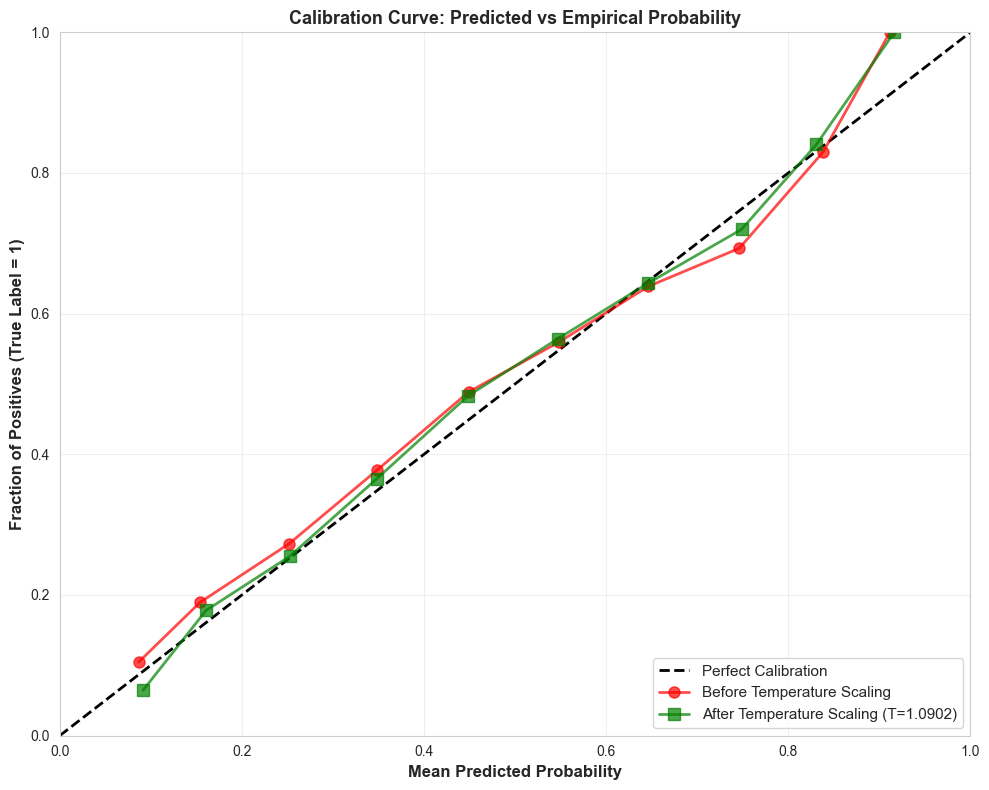


📊 CALIBRATION INTERPRETATION:
Before scaling: Points far from diagonal → model probabilities don't match empirical frequencies
After scaling:  Points closer to diagonal → improved calibration for trustworthy confidence scores


In [68]:
# Collect test set logits for calibration analysis
model.eval()
all_logits_test, all_targets_test = [], []

with torch.no_grad():
    for batch in test_loader:
        output = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            image=batch["image"].to(device),
            metadata=batch["metadata"].to(device),
            has_image=batch["has_image"].to(device)
        )
        all_logits_test.extend(output.cpu().numpy().flatten())
        all_targets_test.extend(batch["label"].numpy())

all_logits_test = np.array(all_logits_test)
all_targets_test = np.array(all_targets_test)

# Compute calibration curves before and after temperature scaling
probs_before = 1 / (1 + np.exp(-all_logits_test))
probs_after = 1 / (1 + np.exp(-all_logits_test / optimal_T))

prob_true_before, prob_pred_before = calibration_curve(
    all_targets_test, 
    probs_before, 
    n_bins=10,
    strategy='uniform'
)

prob_true_after, prob_pred_after = calibration_curve(
    all_targets_test,
    probs_after,
    n_bins=10,
    strategy='uniform'
)

# Visualize calibration curves
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.plot(prob_pred_before, prob_true_before, 'o-', linewidth=2, markersize=8, 
        label=f'Before Temperature Scaling', color='red', alpha=0.7)
ax.plot(prob_pred_after, prob_true_after, 's-', linewidth=2, markersize=8, 
        label=f'After Temperature Scaling (T={optimal_T:.4f})', color='green', alpha=0.7)

ax.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Fraction of Positives (True Label = 1)', fontsize=12, fontweight='bold')
ax.set_title('Calibration Curve: Predicted vs Empirical Probability', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 CALIBRATION INTERPRETATION:")
print(f"Before scaling: Points far from diagonal → model probabilities don't match empirical frequencies")
print(f"After scaling:  Points closer to diagonal → improved calibration for trustworthy confidence scores")

## 11.6 Optimal Threshold Finding



OPTIMAL THRESHOLD FINDING (using F1 score on validation set)
Best Threshold: 0.30 → F1-Score: 0.6423
(Default threshold 0.50 → F1: 0.5506)


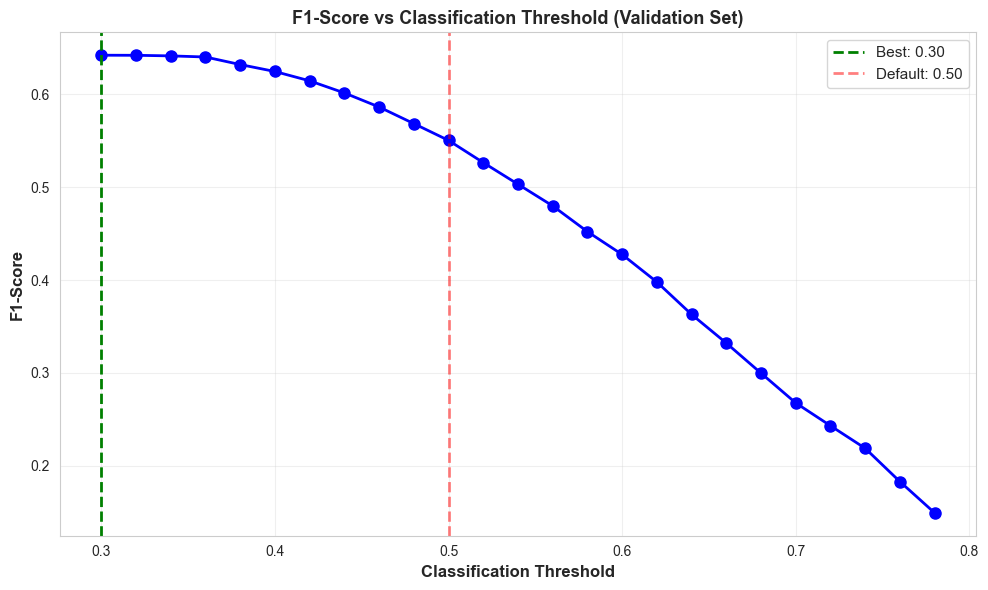

In [69]:
# Find optimal threshold using F1 score on validation set
# CORRECT: Use validation logits (from earlier collection) against validation labels
probs_val_calibrated = 1 / (1 + np.exp(-all_logits_val / optimal_T))

thresholds_to_test = np.arange(0.3, 0.8, 0.02)
f1_scores_by_threshold = []

for threshold in thresholds_to_test:
    val_preds = (probs_val_calibrated > threshold).astype(int)
    f1 = f1_score(all_targets_val, val_preds)
    f1_scores_by_threshold.append(f1)

best_threshold_idx = np.argmax(f1_scores_by_threshold)
best_threshold = thresholds_to_test[best_threshold_idx]
best_f1 = f1_scores_by_threshold[best_threshold_idx]

print(f"\n{'='*60}")
print(f"OPTIMAL THRESHOLD FINDING (using F1 score on validation set)")
print(f"{'='*60}")
print(f"Best Threshold: {best_threshold:.2f} → F1-Score: {best_f1:.4f}")
print(f"(Default threshold 0.50 → F1: {f1_scores_by_threshold[np.argmin(np.abs(thresholds_to_test - 0.5))]:.4f})")

# Visualize F1 score by threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_to_test, f1_scores_by_threshold, 'o-', linewidth=2, markersize=8, color='blue')
ax.axvline(best_threshold, color='green', linestyle='--', linewidth=2, label=f'Best: {best_threshold:.2f}')
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Default: 0.50')
ax.set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('F1-Score vs Classification Threshold (Validation Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

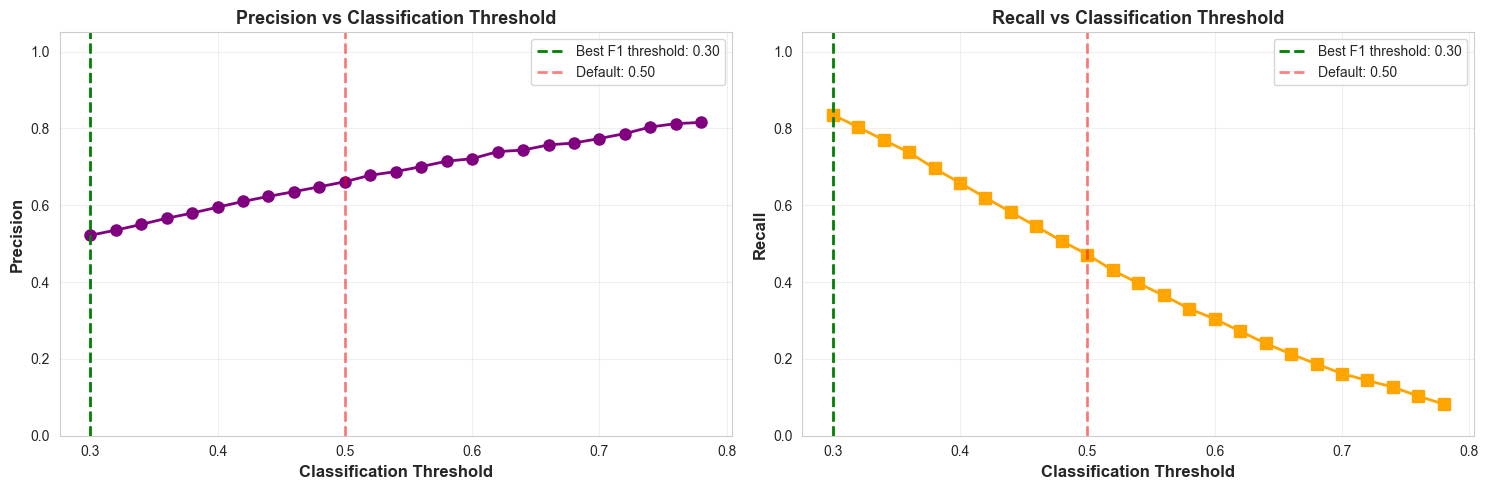


Precision at best threshold (0.30): 0.5217
Recall at best threshold (0.30): 0.8356


In [71]:
# Precision vs Threshold
precision_scores_by_threshold = []
recall_scores_by_threshold = []

for threshold in thresholds_to_test:
    val_preds = (probs_val_calibrated > threshold).astype(int)
    precision = precision_score(all_targets_val, val_preds, zero_division=0)
    recall = recall_score(all_targets_val, val_preds, zero_division=0)
    precision_scores_by_threshold.append(precision)
    recall_scores_by_threshold.append(recall)

# Create side-by-side plots: Precision and Recall vs Threshold
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Precision plot
ax1.plot(thresholds_to_test, precision_scores_by_threshold, 'o-', linewidth=2, markersize=8, color='purple')
ax1.axvline(best_threshold, color='green', linestyle='--', linewidth=2, label=f'Best F1 threshold: {best_threshold:.2f}')
ax1.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Default: 0.50')
ax1.set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax1.set_title('Precision vs Classification Threshold', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Recall plot
ax2.plot(thresholds_to_test, recall_scores_by_threshold, 's-', linewidth=2, markersize=8, color='orange')
ax2.axvline(best_threshold, color='green', linestyle='--', linewidth=2, label=f'Best F1 threshold: {best_threshold:.2f}')
ax2.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Default: 0.50')
ax2.set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
ax2.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax2.set_title('Recall vs Classification Threshold', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"\nPrecision at best threshold ({best_threshold:.2f}): {precision_scores_by_threshold[best_threshold_idx]:.4f}")
print(f"Recall at best threshold ({best_threshold:.2f}): {recall_scores_by_threshold[best_threshold_idx]:.4f}")

## 11.7 Calibration Summary & Deployment Parameters


In [73]:
print(f"\n{'='*70}")
print(f"CALIBRATION & DEPLOYMENT SUMMARY")
print(f"{'='*70}")

print(f"\n1. TEMPERATURE SCALING (Calibration)")
print(f"   → Temperature: {optimal_T:.4f}")
print(f"   → Interpretation: {'Model was OVERCONFIDENT' if optimal_T > 1 else 'Model was UNDERCONFIDENT'}")
print(f"   → Usage: Apply in inference BEFORE sigmoid: sigmoid(logit / {optimal_T:.4f})")
print(f"   → Effect: Improves NLL from {nll_before:.4f} → {nll_after:.4f}")

print(f"\n2. OPTIMAL CLASSIFICATION THRESHOLD (Prediction)")
print(f"   → Threshold: {best_threshold:.4f}")
print(f"   → F1-Score at this threshold: {best_f1:.4f}")
print(f"   → Default threshold (0.5): {f1_scores_by_threshold[np.argmin(np.abs(thresholds_to_test - 0.5))]:.4f}")
print(f"   → Improvement: +{best_f1 - f1_scores_by_threshold[np.argmin(np.abs(thresholds_to_test - 0.5))]:.4f} F1")
print(f"   → Usage: Predict 'Helpful' if calibrated_prob > {best_threshold:.4f}")

print(f"\n3. KEY METRICS")
print(f"   Calibration Metrics:")

tp_probs_summary = test_df_copy[tp_mask]['predicted_prob']
tn_probs_summary = test_df_copy[tn_mask]['predicted_prob']
fp_probs_summary = test_df_copy[fp_mask]['predicted_prob']
fn_probs_summary = test_df_copy[fn_mask]['predicted_prob']
print(f"     TP (correct 'helpful'):    Mean prob = {tp_probs_summary.mean():.4f}")
print(f"     TN (correct 'not helpful'): Mean prob = {tn_probs_summary.mean():.4f}")
print(f"     FP (wrong 'helpful'):       Mean prob = {fp_probs_summary.mean():.4f}")
print(f"     FN (wrong 'not helpful'):   Mean prob = {fn_probs_summary.mean():.4f}")

print(f"\n4. DEPLOYMENT CONFIGURATION")
print(f"   Save these parameters to a config file:")
print(f"   ```yaml")
print(f"   calibration:")
print(f"     temperature: {optimal_T:.6f}")
print(f"     threshold: {best_threshold:.4f}")
print(f"   ```")

print(f"\n5. BUSINESS IMPLICATIONS")
print(f"   ✓ Model probabilities now represent empirical frequencies")
print(f"   ✓ Can confidently set confidence thresholds (e.g., only flag reviews >75% confident)")
print(f"   ✓ Enables transparent, auditable decision-making for stakeholders")
print(f"   ✓ Trade-off: Adjust threshold to balance coverage vs reliability")

print(f"\n{'='*70}\n")



CALIBRATION & DEPLOYMENT SUMMARY

1. TEMPERATURE SCALING (Calibration)
   → Temperature: 1.0902
   → Interpretation: Model was OVERCONFIDENT
   → Usage: Apply in inference BEFORE sigmoid: sigmoid(logit / 1.0902)
   → Effect: Improves NLL from 0.6023 → 0.6017

2. OPTIMAL CLASSIFICATION THRESHOLD (Prediction)
   → Threshold: 0.3000
   → F1-Score at this threshold: 0.6423
   → Default threshold (0.5): 0.5506
   → Improvement: +0.0918 F1
   → Usage: Predict 'Helpful' if calibrated_prob > 0.3000

3. KEY METRICS
   Calibration Metrics:
     TP (correct 'helpful'):    Mean prob = 0.6715
     TN (correct 'not helpful'): Mean prob = 0.2770
     FP (wrong 'helpful'):       Mean prob = 0.6262
     FN (wrong 'not helpful'):   Mean prob = 0.3343

4. DEPLOYMENT CONFIGURATION
   Save these parameters to a config file:
   ```yaml
   calibration:
     temperature: 1.090158
     threshold: 0.3000
   ```

5. BUSINESS IMPLICATIONS
   ✓ Model probabilities now represent empirical frequencies
   ✓ Can conf

## 11.4 Metrics Visualization [Train, Validation, Test]

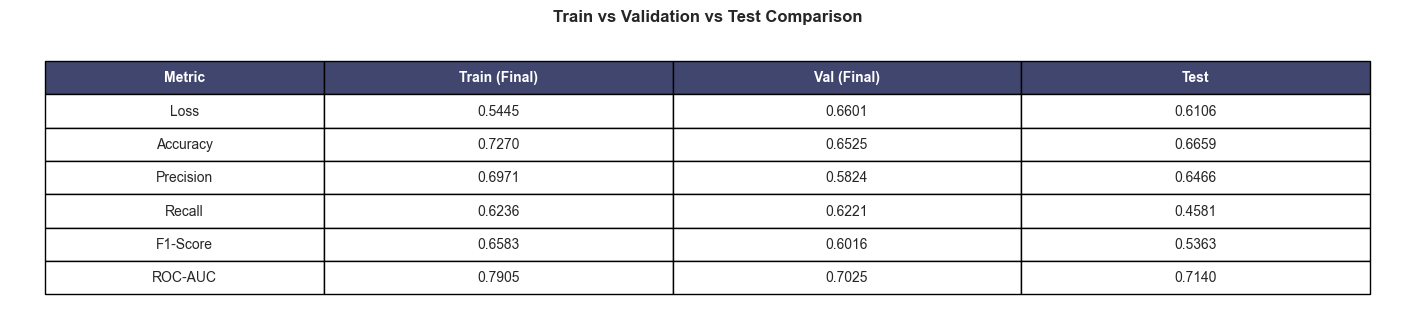

In [32]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')

comparison_data = [
    ['Metric', 'Train (Final)', 'Val (Final)', 'Test'],
    ['Loss', f"{history['train_loss'][-1]:.4f}", f"{history['val_loss'][-1]:.4f}", f"{test_results['Loss']:.4f}"],
    ['Accuracy', f"{history['train_accuracy'][-1]:.4f}", f"{history['val_accuracy'][-1]:.4f}", f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{history['train_precision'][-1]:.4f}", f"{history['val_precision'][-1]:.4f}", f"{test_results['Precision']:.4f}"],
    ['Recall', f"{history['train_recall'][-1]:.4f}", f"{history['val_recall'][-1]:.4f}", f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{history['train_f1'][-1]:.4f}", f"{history['val_f1'][-1]:.4f}", f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{history['train_roc_auc'][-1]:.4f}", f"{history['val_roc_auc'][-1]:.4f}", f"{test_results['ROC-AUC']:.4f}"],
]

comparison_table = ax6.table(cellText=comparison_data, cellLoc='center', loc='center',
                             colWidths=[0.2, 0.25, 0.25, 0.25])

comparison_table.auto_set_font_size(False)
comparison_table.set_fontsize(10)
comparison_table.scale(1, 2)

for i in range(4):
    comparison_table[(0, i)].set_facecolor('#40466e')
    comparison_table[(0, i)].set_text_props(weight='bold', color='white')

ax6.set_title('Train vs Validation vs Test Comparison', fontweight='bold', pad=20)

plt.show()

# 12. Error Analysis 

In [33]:
# Create comprehensive error analysis by modality
test_df_copy = test_df.reset_index(drop=True).copy()
test_df_copy['predicted_prob'] = all_probs
test_df_copy['predicted_label'] = all_preds
test_df_copy['true_label'] = all_targets
test_df_copy['is_correct'] = (test_df_copy['predicted_label'] == test_df_copy['true_label']).astype(int)

## 12.1 Metadata Analysis

In [34]:
# Analyze each metadata feature
metadata_error_analysis = {}

for col in METADATA_COLUMNS:
    if col in test_df_copy.columns:
        # Create bins for continuous features (5 bins)
        if test_df_copy[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            bins = pd.cut(test_df_copy[col], bins=5)
            error_rates = test_df_copy.groupby(bins)['is_correct'].apply(lambda x: 1 - x.mean())
            metadata_error_analysis[col] = error_rates
            
            print(f"\n  {col}:")
            for bin_range, error_rate in error_rates.items():
                count = (bins == bin_range).sum()
                print(f"    {bin_range}: Error Rate = {error_rate:.4f} ({count} reviews)")


  rating:
    (-1.561, -1.074]: Error Rate = 0.3784 (2331 reviews)
    (-1.074, -0.591]: Error Rate = 0.3457 (729 reviews)
    (-0.591, -0.107]: Error Rate = 0.3497 (835 reviews)
    (-0.107, 0.377]: Error Rate = 0.3099 (1268 reviews)
    (0.377, 0.861]: Error Rate = 0.3146 (4800 reviews)

  review_length:
    (-0.741, 2.45]: Error Rate = 0.3376 (9730 reviews)
    (2.45, 5.625]: Error Rate = 0.2041 (196 reviews)
    (5.625, 8.799]: Error Rate = 0.1154 (26 reviews)
    (8.799, 11.974]: Error Rate = 0.1429 (7 reviews)
    (11.974, 15.149]: Error Rate = 0.0000 (4 reviews)

  chars_per_word:
    (-3.291, 1.157]: Error Rate = 0.3400 (9207 reviews)
    (1.157, 5.583]: Error Rate = 0.2564 (737 reviews)
    (5.583, 10.01]: Error Rate = 0.5333 (15 reviews)
    (10.01, 14.436]: Error Rate = 0.0000 (1 reviews)
    (14.436, 18.863]: Error Rate = 0.6667 (3 reviews)

  image_bucket:
    (-0.258, 0.973]: Error Rate = 0.3304 (9253 reviews)
    (0.973, 2.197]: Error Rate = 0.4091 (374 reviews)
    (3.

In [35]:
print("\nMETADATA FEATURES (Overall error rates per feature):")
for col, error_rates in metadata_error_analysis.items():
    print(f"  {col}: Min={error_rates.min():.4f}, Max={error_rates.max():.4f}, Mean={error_rates.mean():.4f}")


METADATA FEATURES (Overall error rates per feature):
  rating: Min=0.3099, Max=0.3784, Mean=0.3397
  review_length: Min=0.0000, Max=0.3376, Mean=0.1600
  chars_per_word: Min=0.0000, Max=0.6667, Mean=0.3593
  image_bucket: Min=0.3304, Max=0.4091, Mean=0.3620
  days_since_first_review: Min=0.1875, Max=0.3557, Mean=0.3110
  is_verified: Min=0.3310, Max=0.3618, Mean=0.3464
  log_popularity: Min=0.2403, Max=0.3938, Mean=0.3227
  rating_extremity: Min=0.3230, Max=0.3497, Mean=0.3360
  question_mark: Min=0.0000, Max=0.3350, Mean=0.1712
  exclamation_mark: Min=0.0000, Max=0.4800, Mean=0.2423
  title_length: Min=0.3125, Max=0.4667, Mean=0.3667
  title_to_text_ratio: Min=0.0000, Max=1.0000, Mean=0.4050


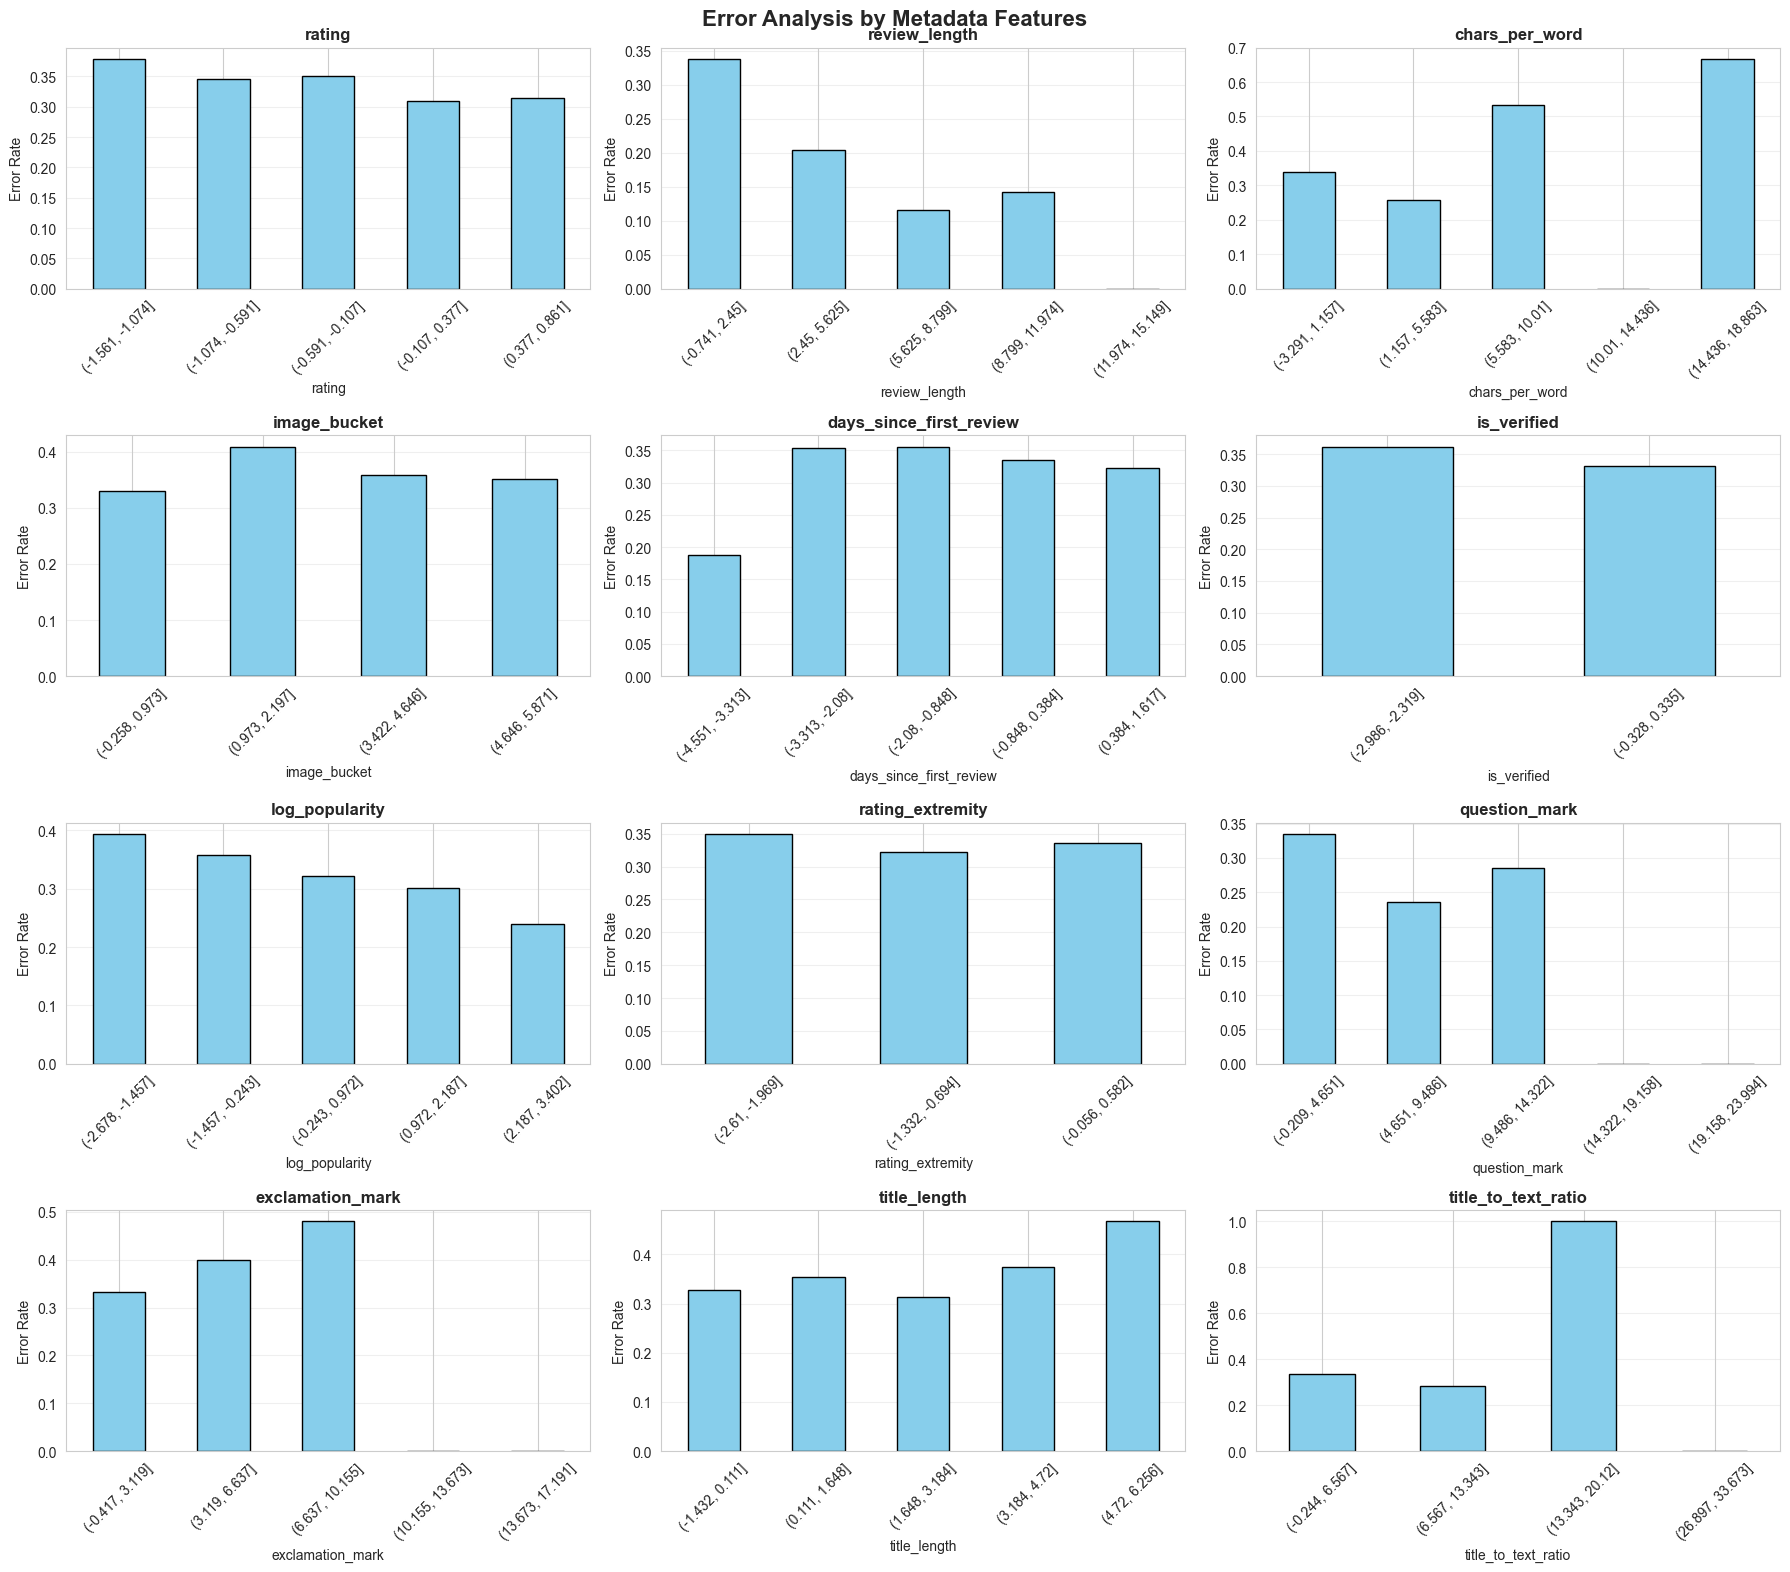

In [36]:
# Visualization: Error rate by metadata features
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
fig.suptitle('Error Analysis by Metadata Features', fontsize=16, fontweight='bold')

for idx, (col, error_rates) in enumerate(metadata_error_analysis.items()):
    if idx < len(axes):
        error_rates.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Error Rate')
        axes[idx].grid(True, alpha=0.3, axis='y')
        axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(metadata_error_analysis), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 12.2 Confusion Outcome Distribution

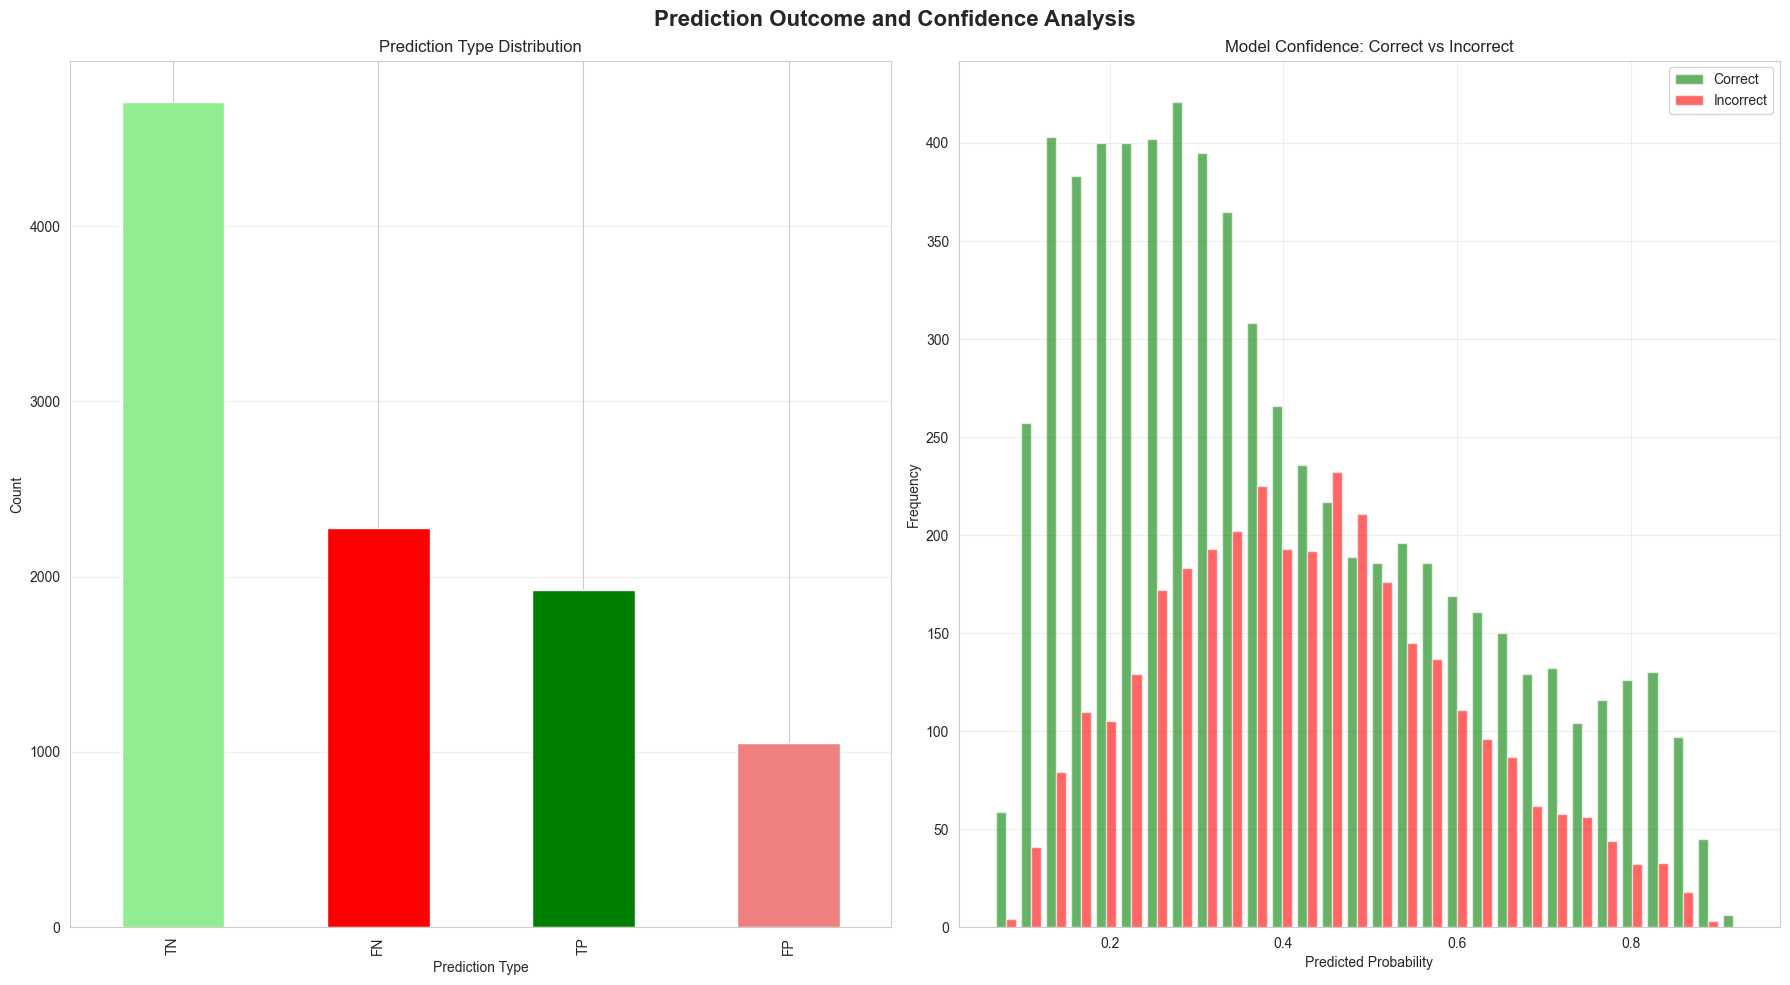

In [37]:
# Classify predictions and visualize error analysis
test_df_copy['error_type'] = test_df_copy.apply(
    lambda x: 'TP' if x['is_correct'] and x['predicted_label'] else
              'TN' if x['is_correct'] else
              'FP' if x['predicted_label'] else 'FN', axis=1
)

# Visualize error distribution and confidence
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Prediction Outcome and Confidence Analysis', fontsize=16, fontweight='bold')

# Error type distribution
error_counts = test_df_copy['error_type'].value_counts()
colors = {tp: c for tp, c in zip(['TP', 'TN', 'FP', 'FN'], ['green', 'lightgreen', 'lightcoral', 'red'])}
error_counts.plot(kind='bar', ax=axes[0], color=[colors.get(x, 'gray') for x in error_counts.index])
axes[0].set(title='Prediction Type Distribution', ylabel='Count', xlabel='Prediction Type')
axes[0].grid(True, alpha=0.3, axis='y')

# Model confidence distribution
correct = test_df_copy[test_df_copy['is_correct'] == 1]['predicted_prob']
incorrect = test_df_copy[test_df_copy['is_correct'] == 0]['predicted_prob']
axes[1].hist([correct, incorrect], bins=30, alpha=0.6, label=['Correct', 'Incorrect'], color=['green', 'red'])
axes[1].set(xlabel='Predicted Probability', ylabel='Frequency', title='Model Confidence: Correct vs Incorrect')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
print(f"\nMODEL CONFIDENCE ANALYSIS (Test Set):")
print(f"\n--- By Correctness (Overall) ---")
correct = test_df_copy[test_df_copy['is_correct'] == 1]['predicted_prob']
incorrect = test_df_copy[test_df_copy['is_correct'] == 0]['predicted_prob']
print(f"  Correct predictions:   Mean prob = {correct.mean():.4f} (n={len(correct)})")
print(f"  Incorrect predictions: Mean prob = {incorrect.mean():.4f} (n={len(incorrect)})")
print(f"  Calibration issue: {'✓ GOOD' if correct.mean() > incorrect.mean() else '✗ BAD'} " + 
      f"(confidence {'correlates with' if correct.mean() > incorrect.mean() else 'does NOT correlate with'} correctness)")

print(f"\n--- By Prediction Type (Detailed) ---")
tp_mask = (test_df_copy['predicted_label'] == 1) & (test_df_copy['true_label'] == 1)
tn_mask = (test_df_copy['predicted_label'] == 0) & (test_df_copy['true_label'] == 0)
fp_mask = (test_df_copy['predicted_label'] == 1) & (test_df_copy['true_label'] == 0)
fn_mask = (test_df_copy['predicted_label'] == 0) & (test_df_copy['true_label'] == 1)

tp_probs = test_df_copy[tp_mask]['predicted_prob']
tn_probs = test_df_copy[tn_mask]['predicted_prob']
fp_probs = test_df_copy[fp_mask]['predicted_prob']
fn_probs = test_df_copy[fn_mask]['predicted_prob']

print(f"  TP (True Positives):   Mean prob = {tp_probs.mean():.4f} (n={len(tp_probs)}) - Should be HIGH")
print(f"  TN (True Negatives):   Mean prob = {tn_probs.mean():.4f} (n={len(tn_probs)}) - Should be LOW")
print(f"  FP (False Positives):  Mean prob = {fp_probs.mean():.4f} (n={len(fp_probs)}) - Should be LOW")
print(f"  FN (False Negatives):  Mean prob = {fn_probs.mean():.4f} (n={len(fn_probs)}) - Should be HIGH")

print(f"\n--- Diagnostic Summary ---")
print(f"  For POSITIVE predictions (pred=1):")
if len(tp_probs) > 0 and len(fp_probs) > 0:
    print(f"    TP mean ({tp_probs.mean():.4f}) vs FP mean ({fp_probs.mean():.4f}) → " + 
          f"{'✓ TP more confident' if tp_probs.mean() > fp_probs.mean() else '✗ FP more confident (BAD!)'}")
print(f"  For NEGATIVE predictions (pred=0):")
if len(tn_probs) > 0 and len(fn_probs) > 0:
    print(f"    TN mean ({tn_probs.mean():.4f}) vs FN mean ({fn_probs.mean():.4f}) → " + 
          f"{'✓ TN more confident' if tn_probs.mean() > fn_probs.mean() else '✗ FN more confident (BAD!)'}")


MODEL CONFIDENCE ANALYSIS:
  Mean confidence on correct predictions: 0.3915
  Mean confidence on incorrect predictions: 0.4265


# 14 Explainability

## 14.1 Text

In [39]:
class TextModelWrapper:
    """Wrapper to make text predictions compatible with SHAP/LIME"""
    def __init__(self, model, tokenizer, device, max_length=MAX_TEXT_LENGTH):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
    
    def predict_text_only(self, texts):
        """Predict using only text (average probability across modalities)"""
        probs = []
        self.model.eval()
        
        with torch.no_grad():
            for text in texts:
                encoding = self.tokenizer(
                    text,
                    padding="max_length",
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt"
                )
                input_ids = encoding["input_ids"].to(self.device)
                attention_mask = encoding["attention_mask"].to(self.device)
                
                # Dummy image and metadata (neutral values)
                image = torch.zeros(1, 3, 224, 224).to(self.device)
                metadata = torch.zeros(1, len(METADATA_COLUMNS)).to(self.device)
                
                # For text-only predictions, assume no image
                has_image_tensor = torch.tensor([0.0]).to(self.device)

                output = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    image=image,
                    metadata=metadata,
                    has_image=has_image_tensor
                )
                prob = torch.sigmoid(output).cpu().numpy()[0]
                probs.append([1 - prob, prob])
        
        return np.array(probs)

In [40]:
# Select a sample review
sample_idx = 0
sample_text = test_df.iloc[sample_idx][TEXT_COLUMN]
true_label = test_df.iloc[sample_idx][LABEL_COLUMN]

print(f"Sample Text: {sample_text[:200]}...")
print(f"True Label: {'Helpful' if true_label == 1 else 'Not Helpful'}")

Sample Text: Get something more sturdy than this one! [SEP] I wanted to like this so I can shoot videos- first of all is hard to ply to get your phone to set in- then I was using it and the wind blew it down toget...
True Label: Not Helpful


In [41]:
# Create wrapper
text_wrapper = TextModelWrapper(model, tokenizer, device)

### LIME

In [42]:
# Create LIME explainer
explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=['Not Helpful', 'Helpful'],
    verbose=False
)

# Get explanation
explanation_lime = explainer_lime.explain_instance(
    sample_text,
    text_wrapper.predict_text_only,
    num_features=10,
    num_samples=100
)


LIME Top Contributing Words:
  hard                 +0.0354  ↑ Helpful
  to                   +0.0273  ↑ Helpful
  SEP                  -0.0255  ↓ Not Helpful
  disaster             +0.0247  ↑ Helpful
  videos               +0.0219  ↑ Helpful
  phone                +0.0210  ↑ Helpful
  blew                 +0.0187  ↑ Helpful
  is                   +0.0140  ↑ Helpful
  of                   -0.0039  ↓ Not Helpful
  sturdy               -0.0028  ↓ Not Helpful


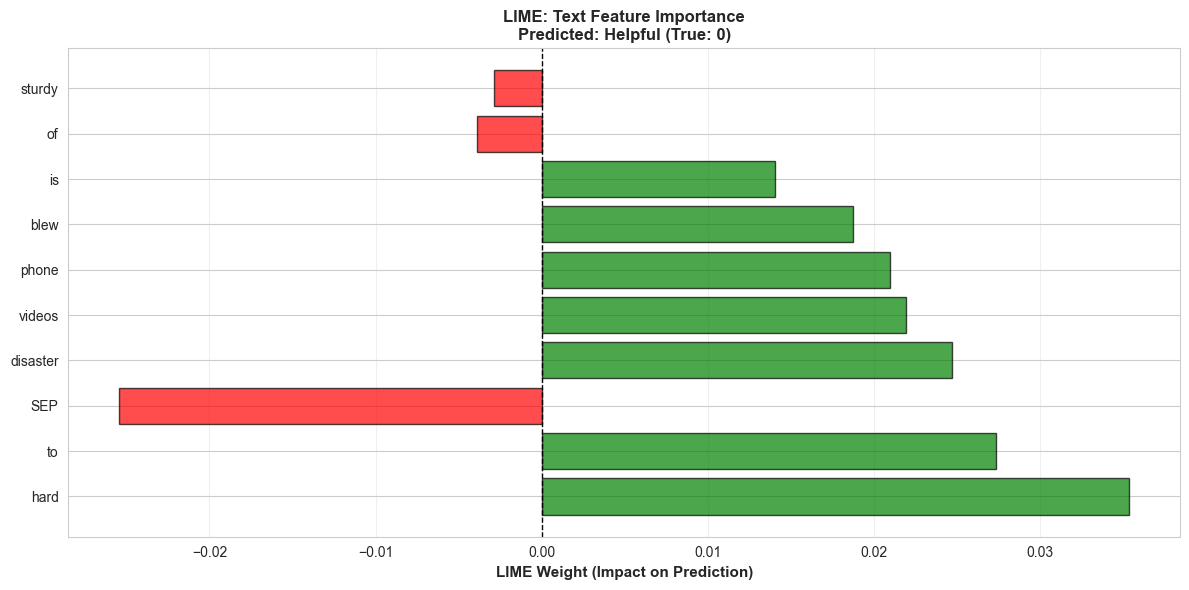

In [43]:
print(f"\nLIME Top Contributing Words:")
for word, weight in explanation_lime.as_list():
    sentiment = "↑ Helpful" if weight > 0 else "↓ Not Helpful"
    print(f"  {word:20s} {weight:+.4f}  {sentiment}")

# Visualize LIME explanation
fig, ax = plt.subplots(figsize=(12, 6))
weights = [weight for _, weight in explanation_lime.as_list()]
words = [word for word, _ in explanation_lime.as_list()]
colors = ['green' if w > 0 else 'red' for w in weights]

bars = ax.barh(range(len(words)), weights, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.set_xlabel('LIME Weight (Impact on Prediction)', fontsize=11, fontweight='bold')
ax.set_title(f'LIME: Text Feature Importance\nPredicted: Helpful (True: {true_label})', 
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### SHAP

In [44]:
# ---- SHAP EXPLANATION FOR TEXT ----
print("\n\nB. SHAP Explanation for Text (using kernel explainer):")

# Sample texts for SHAP background
background_texts = test_df.iloc[:50][TEXT_COLUMN].values

# Create SHAP explainer (kernel explainer for model-agnostic approach)
# Note: This is computationally expensive, so we use fewer background samples
def shap_predict_wrapper(texts):
    """Convert texts to predictions for SHAP"""
    return text_wrapper.predict_text_only(texts)[:, 1]  # Return probability of helpful

# For efficiency, we'll use a simpler approach: feature-based SHAP on tokenized text
print("(Simplified SHAP: Using token importance)")

sample_encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=MAX_TEXT_LENGTH,
    return_tensors="pt"
)
sample_tokens = tokenizer.convert_ids_to_tokens(sample_encoding['input_ids'][0])
sample_tokens = [t for t in sample_tokens if t != '[PAD]']

print(f"Sample tokenized text: {sample_tokens[:20]}")



B. SHAP Explanation for Text (using kernel explainer):
(Simplified SHAP: Using token importance)
Sample tokenized text: ['[CLS]', 'get', 'something', 'more', 'sturdy', 'than', 'this', 'one', '!', '[SEP]', 'i', 'wanted', 'to', 'like', 'this', 'so', 'i', 'can', 'shoot', 'videos']


## 14.2 Metadata

In [45]:
class MetadataModelWrapper:
    """Wrapper to make metadata predictions compatible with SHAP"""
    def __init__(self, model, device, scaler):
        self.model = model
        self.device = device
        self.scaler = scaler
    
    def predict_metadata_only(self, metadata_values):
        """Predict using only metadata (average probability across modalities)"""
        probs = []
        self.model.eval()
        
        with torch.no_grad():
            for row in metadata_values:

                # Dummy text and image
                input_ids = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(self.device)
                attention_mask = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(self.device)
                image = torch.zeros(1, 3, 224, 224).to(self.device)
                
                metadata = torch.tensor(row.astype(np.float32)).unsqueeze(0).to(self.device)
                
                # Extract image_bucket from metadata (it's the 4th column)
                image_bucket_val = int(row[3])  # METADATA_COLUMNS[3] = "image_bucket"
                has_image_tensor = torch.tensor([0.0 if image_bucket_val == 0 else 1.0]).to(self.device)

                output = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    image=image,
                    metadata=metadata,
                    has_image=has_image_tensor
                )
                prob = torch.sigmoid(output).cpu().numpy()[0]
                probs.append(prob)
        
        return np.array(probs)

In [46]:
# Get sample metadata
sample_metadata_idx = 0
sample_metadata = test_df.iloc[sample_metadata_idx][METADATA_COLUMNS].values.reshape(1, -1)
sample_metadata_df = pd.DataFrame(sample_metadata, columns=METADATA_COLUMNS)
sample_metadata_scaled = scaler.transform(sample_metadata_df)[0]

print(f"Sample Metadata (Scaled):")
for col, val in zip(METADATA_COLUMNS, sample_metadata_scaled):
    print(f"  {col:25s}: {val:+.4f}")

Sample Metadata (Scaled):
  rating                   : -3.1054
  review_length            : -0.7318
  chars_per_word           : -9.6897
  image_bucket             : -0.7658
  days_since_first_review  : -5.6082
  is_verified              : -1.8702
  log_popularity           : -4.4638
  rating_extremity         : -1.6794
  question_mark            : -0.4840
  exclamation_mark         : -0.0436
  title_length             : -1.4496
  title_to_text_ratio      : -0.2082


In [47]:
# Create wrapper
metadata_wrapper = MetadataModelWrapper(model, device, scaler)

### SHAP

In [48]:
# Create SHAP explainer for metadata
explainer_shap = shap.KernelExplainer(
    metadata_wrapper.predict_metadata_only,
    shap.sample(test_df[METADATA_COLUMNS].values, min(30, len(test_df))) 
)

# Get SHAP values for sample
shap_values = explainer_shap.shap_values(sample_metadata_scaled)

print(f"\nSHAP Values (Impact on Helpful Prediction):")
for col, val in zip(METADATA_COLUMNS, shap_values):
    sentiment = "↑ Helpful" if val > 0 else "↓ Not Helpful"
    print(f"  {col:25s}: {val:+.6f}  {sentiment}")


SHAP Values (Impact on Helpful Prediction):
  rating                   : +0.060581  ↑ Helpful
  review_length            : -0.006700  ↓ Not Helpful
  chars_per_word           : -0.062923  ↓ Not Helpful
  image_bucket             : +0.008170  ↑ Helpful
  days_since_first_review  : +0.113945  ↑ Helpful
  is_verified              : +0.001201  ↑ Helpful
  log_popularity           : +0.091337  ↑ Helpful
  rating_extremity         : -0.022664  ↓ Not Helpful
  question_mark            : -0.004180  ↓ Not Helpful
  exclamation_mark         : +0.000000  ↓ Not Helpful
  title_length             : -0.002518  ↓ Not Helpful
  title_to_text_ratio      : +0.000000  ↓ Not Helpful


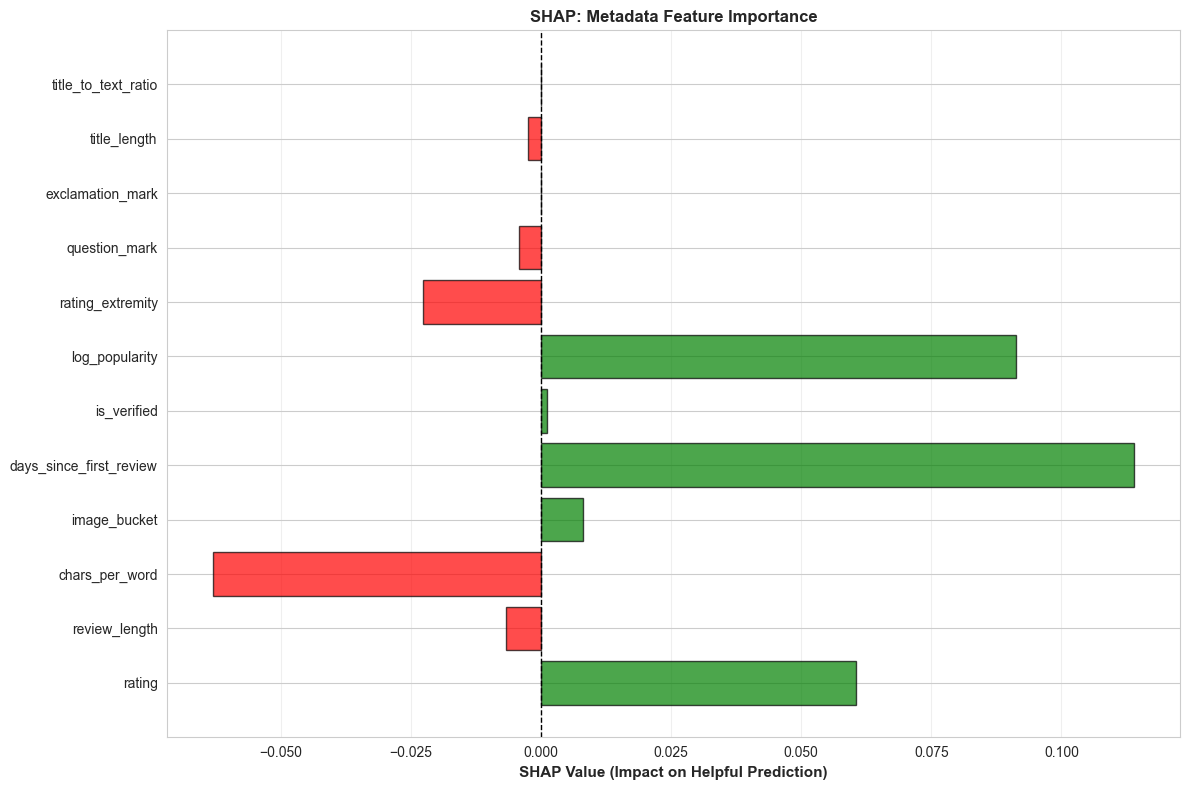

In [49]:
# Visualize SHAP explanation
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['green' if v > 0 else 'red' for v in shap_values]
bars = ax.barh(range(len(METADATA_COLUMNS)), shap_values, color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(METADATA_COLUMNS)))
ax.set_yticklabels(METADATA_COLUMNS, fontsize=10)
ax.set_xlabel('SHAP Value (Impact on Helpful Prediction)', fontsize=11, fontweight='bold')
ax.set_title('SHAP: Metadata Feature Importance', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 14.3 Images

In [50]:
class GradCAM:
    """Grad-CAM implementation for image feature importance"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activations)
        target_layer.register_full_backward_hook(self.save_gradients)
    
    def save_activations(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor):
        """Generate Class Activation Map"""
        # Get device from input tensors
        device = input_tensor['input_ids'].device
        
        # Forward pass - FIXED: Now includes has_image parameter
        output = self.model(
            input_ids=input_tensor['input_ids'],
            attention_mask=input_tensor['attention_mask'],
            image=input_tensor['image'],
            metadata=input_tensor['metadata'],
            has_image=input_tensor.get('has_image', torch.tensor([0.0], device=device))
        )
        
        # Backward pass
        self.model.zero_grad()
        output.backward()
        
        # Handle both 3D and 4D gradient/activation arrays
        gradients = self.gradients.cpu().data.numpy()
        activations = self.activations.cpu().data.numpy()
        
        # If 4D (batch, channels, height, width), take first batch
        if gradients.ndim == 4:
            gradients = gradients[0]
            activations = activations[0]
        
        # Now gradients/activations should be [C, H, W]
        if gradients.ndim != 3:
            print(f"Warning: Unexpected gradient shape {gradients.shape}, skipping CAM")
            return np.zeros((224, 224))
        
        # Weight gradients by average gradient
        weights = np.mean(gradients, axis=(1, 2))  # [C]
        
        # Compute weighted sum
        cam = np.zeros(activations.shape[1:])  # [H, W]
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
        
        # Apply ReLU
        cam = np.maximum(cam, 0)
        
        # Normalize
        cam = cam / (cam.max() + 1e-8)
        
        return cam

In [51]:
# Get sample image - find first valid one
sample_image_idx = None
sample_image_path = None

for idx in range(len(test_df)):
    path = test_df.iloc[idx][IMAGE_PATH_COLUMN]
    if pd.notna(path) and isinstance(path, str):
        sample_image_idx = idx
        sample_image_path = path
        break

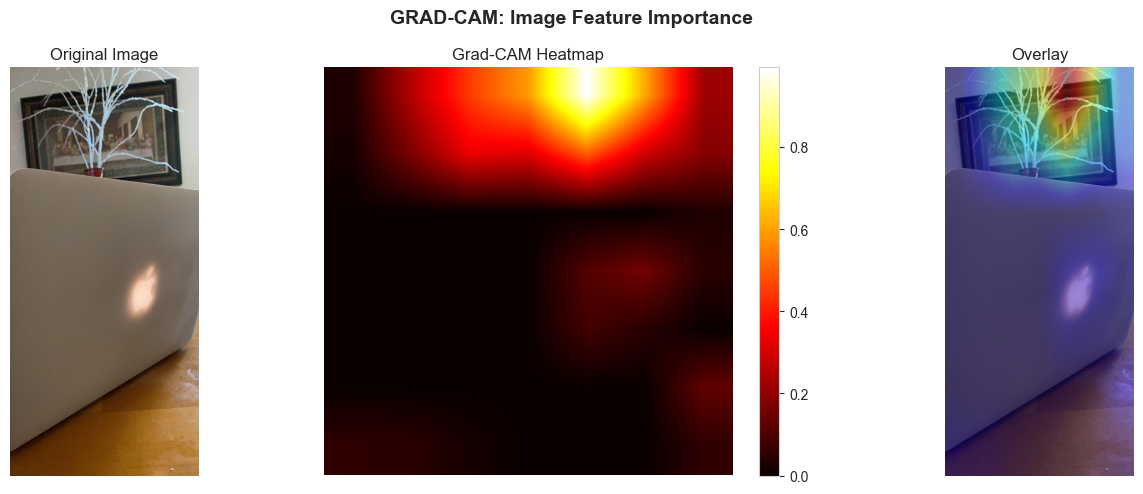

Grad-CAM generated for image: ../data\images\52924.jpg
  Heatmap shows regions important for model prediction
  Red regions: High importance, Green regions: Low importance


In [52]:
if sample_image_idx is not None and sample_image_path is not None:
    full_image_path = sample_image_path
    
    if os.path.exists(full_image_path):
        # Load and process image
        sample_image = Image.open(full_image_path).convert("RGB")
        sample_image_tensor = image_transform(sample_image).unsqueeze(0).to(device)
        
        # Dummy text and metadata
        sample_input_ids = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
        sample_attention_mask = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
        sample_metadata = torch.zeros(1, 12).to(device)
        
        # FIXED: Include has_image in input_dict
        input_dict = {
            'input_ids': sample_input_ids,
            'attention_mask': sample_attention_mask,
            'image': sample_image_tensor,
            'metadata': sample_metadata,
            'has_image': torch.tensor([1.0]).to(device)  # Image successfully loaded
        }
        
        # Create Grad-CAM - hook into features layer for spatial dimensions
        grad_cam = GradCAM(model, model.image_encoder.features[-1])
        cam = grad_cam.generate_cam(input_dict)
        
        # Resize CAM to original image size
        cam_resized = cv2.resize(cam, (224, 224))
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle('GRAD-CAM: Image Feature Importance', fontsize=14, fontweight='bold')
        
        # Original image
        img_array = np.array(sample_image)
        axes[0].imshow(img_array)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        # CAM heatmap
        im = axes[1].imshow(cam_resized, cmap='hot')
        axes[1].set_title('Grad-CAM Heatmap')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1])
        
        # Overlay - ensure CAM matches original image dimensions
        cam_resized = cv2.resize(cam, (img_array.shape[1], img_array.shape[0]))  # (width, height)
        overlay = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
        blended = cv2.addWeighted(img_array, 0.6, overlay, 0.4, 0)
        
        axes[2].imshow(blended)
        axes[2].set_title('Overlay')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Grad-CAM generated for image: {sample_image_path}")
        print(f"  Heatmap shows regions important for model prediction")
        print(f"  Red regions: High importance, Green regions: Low importance")
    else:
        print(f"Warning: Full image path not found: {full_image_path}")
        print("Skipping Grad-CAM visualization")
else:
    print("Warning: No images found in test set")
    print("Skipping Grad-CAM visualization")

# 15. Inference Pipeline

In [ ]:
def predict(model, text, image_path, metadata_values, device=None, temperature=1.0, threshold=0.5):
    """Generate prediction for a single instance with calibration support.
    
    Args:
        model: Trained multimodal model
        text: Review text
        image_path: Path to product image
        metadata_values: List of 12 metadata feature values
        device: Device to run inference on (cuda/cpu)
        temperature: Temperature scaling factor for calibration (default 1.0 = no scaling)
        threshold: Classification threshold (default 0.5)
    
    Returns:
        prob: Calibrated probability (0-1)
        pred: Binary prediction (0 or 1)
    """
    import joblib
    
    # Resolve device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.eval()
    
    # Load scaler for metadata normalization
    if not os.path.exists(MODEL_METADATA_SAVE_PATH):
        raise FileNotFoundError(f"Scaler not found at {MODEL_METADATA_SAVE_PATH}. Please train the model first.")
    scaler = joblib.load(MODEL_METADATA_SAVE_PATH)
    
    # Text - create tensor and move to device immediately
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    # Image - handle missing/corrupted files gracefully
    if not os.path.exists(image_path):
        print(f"Warning: Image not found at {image_path}, using placeholder")
        image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    else:
        try:
            image = Image.open(image_path).convert("RGB")
            image = image_transform(image).unsqueeze(0).to(device)
        except Exception as e:
            print(f"Warning: Could not load image: {e}, using placeholder")
            image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    
    # Metadata - validate, scale, and move to device
    if len(metadata_values) != len(METADATA_COLUMNS):
        raise ValueError(f"Expected {len(METADATA_COLUMNS)} metadata values, got {len(metadata_values)}")
    
    # Scale metadata using trained scaler
    metadata_scaled = scaler.transform([metadata_values])[0]
    metadata = torch.tensor(metadata_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Determine if image was successfully loaded
    has_image_val = 1.0 if os.path.exists(image_path) else 0.0

    with torch.no_grad():
        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata,
            has_image=torch.tensor([has_image_val]).to(device)
        )
        
        # Apply temperature scaling for calibration
        logit_scaled = output / temperature
        prob = torch.sigmoid(logit_scaled).item()
        
        # Apply threshold for binary prediction
        pred = 1 if prob > threshold else 0
    
    return prob, pred

In [55]:
prob, pred = predict(
    model=model,
    text="Great product! Very satisfied.",
    image_path="../data/images/123.jpg",
    metadata_values=[5, 150, 4.2, 1.0, 45, 1, 3.5, 2, 1, 0, 120, 0.8],
    device="cuda",
    temperature=optimal_T,
    threshold=best_threshold
)
print(f"\nCalibrated probability: {prob:.2%}")
print(f"Binary prediction (threshold={best_threshold:.2f}): {'Helpful' if pred == 1 else 'Not Helpful'}")
print(f"\nNote: Temperature={optimal_T:.4f} (calibration), Threshold={best_threshold:.2f} (optimal F1)")


Probability this review is helpful: 26.00%


c:\Users\knowu\miniconda3\envs\aidl-grp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
